<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
Why is this problem important to solve?

ChicStyle is a growing fashion retail platform that sees massive spikes in customer activity during festive seasons and holiday sales. As shoppers buy clothing and accessories for celebrations, the volume of incoming reviews rises sharply — they arrive every hour, ranging from positive praise to urgent complaints about fit, delivery delays, product defects, or sizing issues. During these high-pressure periods, even a slight delay in reading or responding to feedback can have serious consequences. If the retail team fails to act quickly, customers feel ignored at an emotionally significant time, which leads to frustration, spoiled shopping experiences, and reduced trust in the brand. The cost is twofold: immediate lost sales, and longer-term damage to repeat purchases and loyalty. To protect both revenue and reputation at peak periods, ChicStyle needs a system that can process thousands of reviews instantly, accurately, and with business context.

Customer reviews are direct, unsolicited signals about what is working and what is failing across the product and service experience. Analyzing them well lets a retailer:

- **Catch problems early** — defects, sizing inconsistencies, and delivery failures surface in reviews before they show up in returns and churn.
- **Prioritize action** — separating urgent complaints from minor suggestions lets limited support and operations capacity focus where it matters most.
- **Improve products faster** — recurring themes (e.g., a dress that runs small) feed directly back to merchandising and quality teams.
- **Protect brand reputation and loyalty** — responding promptly, especially to negative feedback, signals that the brand listens and converts a bad experience into a recoverable one.
- **Turn unstructured text into business intelligence** — at scale, reviews become a measurable, trackable input to decisions rather than anecdotes.

The challenge is volume and nuance. Traditional rule-based NLP struggles with mixed feedback — for example, *"The fit is great but the color was not as per the product image"* contains both a positive and a negative opinion, and older systems tend to collapse it into a single sentiment, losing critical detail. This is precisely the gap a Generative AI approach is meant to close.


### **Objective**
What is the intended goal?

Build a **Generative AI feedback system** that uses prompt engineering — **Zero-Shot, Few-Shot, and Chain-of-Thought (CoT)** prompting — to transform large volumes of raw customer reviews into structured, actionable intelligence. Specifically, the system should:

- **Analyze and categorize sentiment in real time** (positive, negative, neutral), including mixed feedback.
- **Detect which product or service** each piece of feedback refers to (e.g., fit, quality, delivery, price), even though there is no explicit service column — it is inferred from the review text.
- **Summarize insights by product category and urgency level**, where category comes from existing department data and urgency (high / medium / low) is inferred from the language of the review.
- **Automatically send short, personalized messages** to customers based on sentiment — thanking them for positive feedback, acknowledging neutral comments, and apologizing for negative ones while letting them know a team member will follow up.
- **Generate short, actionable reports** for retail teams.

Manual review reading does not scale to thousands of reviews per hour during peak sales, and it is slow, inconsistent, and expensive. Automating it lets ChicStyle:

- **Respond in real time** rather than hours or days later, so customers feel heard during emotionally important purchases.
- **Act on issues quickly** — high-urgency complaints are flagged and routed instead of being buried in a backlog.
- **Improve product quality faster** by surfacing recurring themes automatically.
- **Apply consistent, context-aware judgment** at scale, capturing nuance that rule-based models miss.
- **Free up human teams** to focus on resolution and relationships instead of triage.

In short, the goal is to turn massive unstructured feedback into meaningful, real-time business intelligence that protects revenue, reputation, and loyalty during the moments that matter most.

### **Dataset Used for the Notebook**
Describe dataset used for this project.

#### **Description**

The project uses the **"Women's E-Commerce Clothing Reviews"** dataset: **23,486 reviews with 10 columns**. 
Each row is a single customer review of a clothing item, combining structured metadata (rating, recommendation, department) with unstructured review text.

| Column                  | Description                                                  | Type             |
| ----------------------- | ------------------------------------------------------------ | ---------------- |
| Clothing.ID             | Unique ID for each piece of clothing                         | Integer          |
| Age                     | Age of the reviewer                                          | Positive integer |
| Title                   | Title of the review                                          | String           |
| Review.Text             | Main body of the review                                      | String           |
| Rating                  | Product score, 1 (worst) to 5 (best)                         | Ordinal integer  |
| Recommended.IND         | Whether the customer recommends the product (1 = yes, 0 = no) | Binary           |
| Positive.Feedback.Count | Number of other customers who found the review helpful       | Positive integer |
| Division.Name           | High-level division of the product                           | Categorical      |
| Department.Name         | Specific department of the product                           | Categorical      |
| Class.Name              | Product class (finer than department)                        | Categorical      |

Reviewers skew middle-aged: ages range from **18 to 99** with a **mean of ~43** and a median of 41. Reviews average about **60 words** each.

> **Note on scope:** For the GenAI prompt-engineering and evaluation work, only a **sample of 50 reviews** is processed (5–10 during initial prompt testing, scaling to 50 for final evaluation) to stay within the API budget. The full 23,486-row dataset is only used for the exploratory analysis.

#### **Key Patterns Summary**
*Ratings — strongly skewed positive:*

| Rating | Count  | Share |
| ------ | ------ | ----- |
| 5      | 13,131 | 55.9% |
| 4      | 5,077  | 21.6% |
| 3      | 2,871  | 12.2% |
| 2      | 1,565  | 6.7%  |
| 1      | 842    | 3.6%  |

About **77.5% of reviews are 4–5 stars** and **82.2% of customers recommend** the product. This class imbalance matters: negative reviews are the minority but carry the highest business urgency, so the system must not let the volume of praise drown out the smaller stream of complaints. Rating aligns tightly with recommendation — the average rating is **4.6 among recommenders vs. 2.3 among non-recommenders** — confirming the two signals are consistent.

*Departments — concentrated in a few categories:*

| Department | Count  |
| ---------- | ------ |
| Tops       | 10,468 |
| Dresses    | 6,319  |
| Bottoms    | 3,799  |
| Intimate   | 1,735  |
| Jackets    | 1,032  |
| Trend      | 119    |

**Tops and Dresses together account for ~71%** of all reviews, so feedback volume — and therefore the operational load and the biggest opportunity for product improvement — is concentrated there. At the division level, **General (13,850)** and **General Petite (8,120)** dominate, with Intimates smallest. The finest level (Class.Name) is led by Dresses, Knits, and Blouses.

*Fit and sizing dominate both ends:*

- **Positive reviews (4–5★):** *love, great, perfect, fit, size, fabric, color, dress, top, comfortable* — praise centers on fit, fabric, and overall delight.
- **Negative reviews (1–2★):** *too, small, fabric, fit, size, ordered, look, back* — complaints cluster around **fit/sizing** ("too small"), **fabric quality**, and **returns** ("ordered… back").

The recurring takeaway is that **fit and sizing are the single most important theme across the entire experience** — they drive both the strongest praise and the strongest complaints. Fabric/quality and color-vs-image expectations are the next most common pain points.

#### **Data treatments / preprocessing required**
- **Missing values:** `Review.Text` is missing in **845 rows** and `Title` in **3,810 rows**; `Division.Name`, `Department.Name`, and `Class.Name` are each missing in **14 rows**. Rows with no review text cannot be analyzed by the language model and should be dropped (or excluded from the sampled set); the 14 rows missing category fields can be dropped or imputed as "Unknown."
- **CSV parsing:** the file is **semicolon-delimited** with an unnamed leading index column — it must be read with the correct separator and index handling, and review text contains embedded quotes/commas that must be parsed cleanly.
- **Text cleaning for analysis:** for EDA and word clouds, lowercase the text, strip punctuation, and remove stopwords; keep the raw text intact for the LLM so it retains nuance.
- **Sampling:** draw a representative ~50-review sample for prompt experiments, ideally spanning the rating range and major departments so evaluation isn't dominated by 5-star Tops reviews.
- **Type checks:** confirm `Rating` (1–5) and `Recommended.IND` (0/1) fall in valid ranges; treat `Rating`, `Department.Name`, and `Division.Name` as categ/ordinal as appropriate.
- **No new labels needed for category/urgency:** the project intentionally does **not** add sentiment, "Category," or "urgency" columns to the data — these are generated by the LLM from the review text at analysis time, with product category drawn from the existing `Department.Name`.

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [190]:
# Install the required libraries for the project
# We use `uv` (a fast Python package manager) instead of pip.
# The `!` prefix runs these as shell commands from within the notebook.
# `uv add` adds each package to the project's environment (pyproject.toml / uv.lock).

# --- Data handling & numerical computing ---
!uv add numpy pandas

# --- Visualization libraries ---
!uv add matplotlib seaborn wordcloud plotly

# --- Machine learning metrics (scikit-learn) ---
!uv add scikit-learn

# --- Progress bars for long-running loops ---
!uv add tqdm

# --- OpenAI client for LLM-based analysis ---
!uv add openai

# --- IPython for rich in-notebook display (display, etc.) ---
!uv add ipython


Resolved 76 packages in 15ms
Audited 71 packages in 19ms
Resolved 76 packages in 3ms
Audited 71 packages in 4ms
Resolved 76 packages in 3ms
Audited 71 packages in 4ms
Resolved 76 packages in 3ms
Audited 71 packages in 4ms
Resolved 76 packages in 3ms
Audited 71 packages in 4ms
Resolved 76 packages in 3ms
Audited 71 packages in 2ms


In [191]:
# Import the required libraries for the project

# --- Core Utilities ---
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

# --- Data Handling ---
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- Progress Bar ---
from tqdm import tqdm

# --- OpenAI Client ---
import openai

# Set global plot style
sns.set_style("whitegrid")


### **Data Loading**
### Loading and Understanding the Data


In [192]:
### Loading and Understanding the Data
# Load the dataset from 'data/Dataset - Real-Time Retail Feedback Intelligence.csv'. 
# Note: the separator is a semicolon (';') and the first column should be used as the index.

# Path to the dataset file:
data_path = "data/Dataset - Real-Time Retail Feedback Intelligence.csv"

# Read the CSV into a DataFrame:
# - sep=";"      -> the file uses a semicolon as the column separator
# - index_col=0  -> use the first (unnamed) column as the DataFrame index
df = pd.read_csv(data_path, sep=";", index_col=0)

# Display the loaded DataFrame to verify it was read correctly
display(df)

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


### **Data Overview**


#### Dimensions and First few rows of the dataset

In [193]:
# ----------------------------------------------------------------------
# Data Overview
# A quick, structured look at the dataset before any cleaning/analysis.
# ----------------------------------------------------------------------

# First few rows of the dataset
# head() shows the top 5 rows so we can eyeball the structure and values.
print("First few rows of the dataset:")
display(df.head())

# Dimensions
# shape returns a (rows, columns) tuple describing the size of the data.
print(f"\nDimensions (rows, columns): {df.shape}")
print(f"- Number of rows (records): {df.shape[0]}")
print(f"- Number of columns (features): {df.shape[1]}")



First few rows of the dataset:


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Dimensions (rows, columns): (23486, 10)
- Number of rows (records): 23486
- Number of columns (features): 10


#### Column Details

In [194]:
# Column Names
# The list of all column labels in the DataFrame.
print("\nColumn Names:")
print(df.columns.tolist())

# Column Types, total and non-null Counts
# info() summarizes the dtype and the number of non-null values per column, which helps quickly spot columns with missing data.
print("\nColumn Types, total and non-null counts:")
df.info()



Column Names:
['Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']

Column Types, total and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing.ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review.Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended.IND          23486 non-null  int64
 6   Positive.Feedback.Count  23486 non-null  int64
 7   Division.Name            23472 non-null  str  
 8   Department.Name          23472 non-null  str  
 9   Class.Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


#### Statistical summary of numerical columns

In [195]:
# Statistical summary of numerical columns
# describe() reports count, mean, std, min, quartiles and max for numeric columns.
print("\nStatistical summary of numerical columns:")
display(df.describe())



Statistical summary of numerical columns:


,Clothing.ID,Age,Rating,Recommended.IND,Positive.Feedback.Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [196]:
# Memory Usage
# memory_usage(deep=True) accounts for the true size of object/string columns. Printing both per-column breakdown and the total footprint in MB.
print("\nMemory Usage (bytes per column):")
mem_usage = df.memory_usage(deep=True)
display(mem_usage)
print(f"- Total memory usage: {mem_usage.sum() / (1024 ** 2):.2f} MB")


Memory Usage (bytes per column):


Index                          132
Clothing.ID                 187888
Age                         187888
Title                      1461792
Review.Text                8127461
Rating                      187888
Recommended.IND             187888
Positive.Feedback.Count     187888
Division.Name              1374724
Department.Name            1284973
Class.Name                 1302280
dtype: int64

- Total memory usage: 13.82 MB


### **Sanity checks**

#### Duplicate Rows

In [197]:
# ----------------------------------------------------------------------
# Dataset Sanity Checks
# Basic data-quality checks before cleaning and analysis.
# ----------------------------------------------------------------------

# Duplicate Rows
# duplicated() identifies rows that exactly match an earlier row.
print("Duplicate Rows:")
num_duplicates = df.duplicated().sum()
print(f"- Total duplicate rows: {num_duplicates}")

# If duplicates exist, show a small sample to inspect them.
if num_duplicates > 0:
    print("- Sample duplicate rows:")
    display(df[df.duplicated(keep=False)].head())


Duplicate Rows:
- Total duplicate rows: 21
- Sample duplicate rows:


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
299,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
494,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
1005,1094,30,NaN,NaN,5,1,0,General,Dresses,Dresses
2740,1094,36,NaN,NaN,5,1,0,General Petite,Dresses,Dresses
2942,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses


#### Missing Values

In [198]:
# Missing Values
# isna() counts NaN/None values per column; percentages help compare columns.
print("\nMissing Values:")
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct,
})

# Show only columns that actually have missing values.
display(missing_summary[missing_summary["missing_count"] > 0])



Missing Values:


,missing_count,missing_percentage
Title,3810,16.22
Review.Text,845,3.60
Division.Name,14,0.06
Department.Name,14,0.06
Class.Name,14,0.06


#### Unique Values

In [199]:

# Unique Values
# nunique() counts distinct values in each column (NaN is excluded by default).
print("\nUnique Values (per column):")
unique_counts = df.nunique()
display(unique_counts.to_frame(name="unique_count"))

# Non-empty and unique value counts for each column
# For text columns, blank strings are treated as empty in addition to NaN.
print("\nNon-empty and unique value counts for each column:")

def count_non_empty(series: pd.Series) -> int:
    """Count values that are present and not blank (for string/object columns)."""
    if series.dtype == "object" or pd.api.types.is_string_dtype(series):
        return series.dropna().astype(str).str.strip().ne("").sum()
    return series.notna().sum()

sanity_summary = pd.DataFrame({
    "non_empty_count": [count_non_empty(df[col]) for col in df.columns],
    "unique_count": [df[col].nunique() for col in df.columns],
}, index=df.columns)

# Derived count: rows that are missing or blank for each column.
sanity_summary["empty_or_missing_count"] = len(df) - sanity_summary["non_empty_count"]

display(sanity_summary)


Unique Values (per column):


,unique_count
Clothing.ID,1206
Age,77
Title,13993
Review.Text,22634
Rating,5
Recommended.IND,2
Positive.Feedback.Count,82
Division.Name,3
Department.Name,6
Class.Name,20



Non-empty and unique value counts for each column:


,non_empty_count,unique_count,empty_or_missing_count
Clothing.ID,23486,1206,0
Age,23486,77,0
Title,19676,13993,3810
Review.Text,22641,22634,845
Rating,23486,5,0
Recommended.IND,23486,2,0
Positive.Feedback.Count,23486,82,0
Division.Name,23472,3,14
Department.Name,23472,6,14
Class.Name,23472,20,14


### Data Observation Summary

In [200]:
# ----------------------------------------------------------------------
# Summary of all observations from Data Overview and Sanity Checks
# Consolidates key findings into a readable narrative before cleaning/EDA.
# ----------------------------------------------------------------------

# Recompute helper metrics so this cell can run independently if needed.
def count_non_empty(series: pd.Series) -> int:
    """Count values that are present and not blank (for string/object columns)."""
    if series.dtype == "object" or pd.api.types.is_string_dtype(series):
        return series.dropna().astype(str).str.strip().ne("").sum()
    return series.notna().sum()

column_counts = pd.DataFrame({
    "non_empty_count": [count_non_empty(df[col]) for col in df.columns],
    "unique_count": [df[col].nunique() for col in df.columns],
}, index=df.columns)

num_duplicates = df.duplicated().sum()
total_missing = df.isna().sum().sum()
missing_by_col = df.isna().sum()
cols_with_missing = missing_by_col[missing_by_col > 0]
int_cols = df.select_dtypes(include=["int64"]).columns.tolist()
str_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
total_memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("=" * 80)
print("SUMMARY OF OBSERVATIONS")
print("=" * 80)

print("")
print("1. DATASET LOADING")
print(f"   - The Real-Time Retail Feedback Intelligence dataset has been loaded successfully.")
print(f"   - The dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"   - The file was read as a semicolon-delimited CSV with the first column used as the index.")
print(f"   - The first few rows show customer review records with product, rating, and category fields.")
print(f"   - No obvious loading issues such as misaligned columns or unexpected headers were observed.")

print("")
print("2. DATASET DIMENSIONS & COLUMNS")
print(f"   - Shape: {df.shape[0]:,} observations x {df.shape[1]} variables")
print(f"   - Columns: {', '.join(df.columns.tolist())}")
print(f"   - `Review.Text` is the most critical feature for LLM-based analysis.")
print(f"   - `Recommended.IND` is the binary recommendation label (1 = yes, 0 = no).")
print(f"   - `Rating`, `Division.Name`, `Department.Name`, and `Class.Name` provide review score and product context.")

print("")
print("3. DATA TYPES")
print(f"   - The dataset contains a mix of numeric and text fields suitable for NLP and classification tasks.")
print(f"   - {len(int_cols)} columns are int64: {', '.join(int_cols)}.")
print(f"   - {len(str_cols)} columns are string/object: {', '.join(str_cols)}.")
print(f"   - `Recommended.IND` is a binary indicator with values {sorted(df['Recommended.IND'].unique().tolist())}.")
print(f"   - `Rating` is an ordinal score from {df['Rating'].min()} to {df['Rating'].max()}.")

print("")
print("4. MISSING VALUES")
print(f"   - Total missing values in the dataset: {total_missing:,}")
if len(cols_with_missing) > 0:
    for col_name, miss_count in cols_with_missing.items():
        miss_pct = (miss_count / len(df) * 100)
        print(f"   - {col_name}: {miss_count:,} missing ({miss_pct:.2f}%)")
    print(f"   - Rows with missing `Review.Text` cannot be analyzed by the language model and should be dropped.")
    print(f"   - Rows with missing category fields can be dropped or imputed as 'Unknown'.")
else:
    print(f"   - Each column has 0 missing values.")
    print(f"   - No missing value treatment is required at this stage.")

print("")
print("5. DUPLICATE ROWS")
print(f"   - Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    print(f"   - A small number of exact duplicate records were found and should be reviewed during cleaning.")
else:
    print(f"   - The dataset does not contain duplicate records.")

print("")
print("6. NON-EMPTY & UNIQUE VALUE COUNTS")
print("   - Display counts in aligned columns for easier reading:")

# Display counts in aligned columns for easier reading.
aligned_counts = column_counts.astype(int).rename(
    columns={"non_empty_count": "Non-Empty", "unique_count": "Unique"}
)
aligned_counts.index.name = "Column"
print(aligned_counts.to_string())

print("")
print("7. KEY STATISTICAL OBSERVATIONS")
print(f"   - Rating: mean = {df['Rating'].mean():.2f}, median = {df['Rating'].median():.0f}, "
      f"std = {df['Rating'].std():.2f}, range = {df['Rating'].min()} to {df['Rating'].max()}")
print(f"   - Recommended.IND: mean = {df['Recommended.IND'].mean():.2f} "
      f"({df['Recommended.IND'].mean() * 100:.1f}% of reviews recommend the product)")
print(f"   - Age: mean = {df['Age'].mean():.2f}, range = {df['Age'].min()} to {df['Age'].max()}")
print(f"   - Positive.Feedback.Count: mean = {df['Positive.Feedback.Count'].mean():.2f}, "
      f"max = {df['Positive.Feedback.Count'].max()} (right-skewed; most reviews have few helpful votes)")
print(f"   - Clothing.ID: {df['Clothing.ID'].nunique():,} unique product IDs across the review records")
print(f"   - Division.Name: {df['Division.Name'].nunique()} unique values "
      f"({', '.join(df['Division.Name'].dropna().unique().astype(str).tolist())})")
print(f"   - Department.Name: {df['Department.Name'].nunique()} unique departments; "
      f"top department is '{df['Department.Name'].value_counts().idxmax()}'")
print(f"   - Class.Name: {df['Class.Name'].nunique()} unique product classes")

print("")
print("8. MEMORY USAGE")
print(f"   - Total memory usage: {total_memory_mb:.2f} MB")
print(f"   - Text columns (`Title`, `Review.Text`) contribute most of the memory footprint.")

print("")
print("9. OVERALL CONCLUSION")
print(f"   - The dataset is structurally consistent and suitable for retail feedback analysis.")
print(f"   - Missing review text and a small number of duplicate rows require attention before modeling.")
print(f"   - Numeric fields (`Rating`, `Recommended.IND`, `Positive.Feedback.Count`) are complete and valid.")
print(f"   - The data is ready for cleaning, exploratory data analysis, and LLM prompt experimentation.")

print("")
print("=" * 80)

SUMMARY OF OBSERVATIONS

1. DATASET LOADING
   - The Real-Time Retail Feedback Intelligence dataset has been loaded successfully.
   - The dataset contains 23,486 rows and 10 columns.
   - The file was read as a semicolon-delimited CSV with the first column used as the index.
   - The first few rows show customer review records with product, rating, and category fields.
   - No obvious loading issues such as misaligned columns or unexpected headers were observed.

2. DATASET DIMENSIONS & COLUMNS
   - Shape: 23,486 observations x 10 variables
   - Columns: Clothing.ID, Age, Title, Review.Text, Rating, Recommended.IND, Positive.Feedback.Count, Division.Name, Department.Name, Class.Name
   - `Review.Text` is the most critical feature for LLM-based analysis.
   - `Recommended.IND` is the binary recommendation label (1 = yes, 0 = no).
   - `Rating`, `Division.Name`, `Department.Name`, and `Class.Name` provide review score and product context.

3. DATA TYPES
   - The dataset contains a mix o

### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

In [201]:
# ----------------------------------------------------------------------
# Data Cleaning and Preprocessing - Initial Cleaning (Before EDA)
# Goal: fix structural issues and remove unusable records only.
# Deeper missing-value treatment and text normalization will be performed after EDA.
# ----------------------------------------------------------------------

# Keep a snapshot of the original shape for a before/after summary.
rows_before = df.shape[0]
print("=" * 80)
print("INITIAL DATA CLEANING (BEFORE EDA)")
print("=" * 80)
print(f"Starting shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Work on a copy so the raw-loaded data is not overwritten in memory.
df_clean = df.copy()

# ------------------------------------------------------------------
# 1. Identify and remove duplicate rows
# ------------------------------------------------------------------
duplicate_count = df_clean.duplicated().sum()
print(f"\n1. Duplicate Rows")
print(f"   - Duplicate rows found: {duplicate_count}")

df_clean = df_clean.drop_duplicates(keep="first")
print(f"   - Rows removed: {duplicate_count}")
print(f"   - Shape after duplicate removal: {df_clean.shape[0]:,} rows")

# ------------------------------------------------------------------
# 2. Fix incorrect or mixed data types
# ------------------------------------------------------------------
print(f"\n2. Data Type Corrections")

# Numeric fields should be stored as integers for downstream analysis.
numeric_cols = [
    "Clothing.ID",
    "Age",
    "Rating",
    "Recommended.IND",
    "Positive.Feedback.Count",
]

for col in numeric_cols:
    # errors='coerce' turns any non-numeric values into NaN so they can be flagged later.
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Text fields should be consistently stored as pandas string dtype.
text_cols = ["Title", "Review.Text", "Division.Name", "Department.Name", "Class.Name"]
for col in text_cols:
    df_clean[col] = df_clean[col].astype("string")

# Cast valid numeric columns back to nullable integer types where appropriate.
for col in numeric_cols:
    df_clean[col] = df_clean[col].astype("Int64")

print(f"   - Enforced integer types for: {', '.join(numeric_cols)}")
print(f"   - Enforced string types for: {', '.join(text_cols)}")

# ------------------------------------------------------------------
# 3. Handle obvious, fatal errors in key numeric fields
# ------------------------------------------------------------------
print(f"\n3. Fatal Error Handling")

# Build a single mask for rows that are clearly invalid and cannot be used safely.
invalid_mask = (
    df_clean["Clothing.ID"].isna() | (df_clean["Clothing.ID"] <= 0)
    | df_clean["Age"].isna() | (df_clean["Age"] < 10) | (df_clean["Age"] > 100)
    | df_clean["Rating"].isna() | ~df_clean["Rating"].isin([1, 2, 3, 4, 5])
    | df_clean["Recommended.IND"].isna() | ~df_clean["Recommended.IND"].isin([0, 1])
    | df_clean["Positive.Feedback.Count"].isna() | (df_clean["Positive.Feedback.Count"] < 0)
)

fatal_error_count = invalid_mask.sum()
print(f"   - Rows with invalid numeric values: {fatal_error_count}")

# Review text is required for LLM-based analysis; blank or whitespace-only text is unusable.
blank_review_mask = df_clean["Review.Text"].fillna("").str.strip().eq("")
blank_review_count = blank_review_mask.sum()
print(f"   - Rows with missing or blank Review.Text: {blank_review_count}")

# Remove all fatal-error rows in one step.
rows_to_drop = invalid_mask | blank_review_mask
df_clean = df_clean.loc[~rows_to_drop].copy()
print(f"   - Total rows removed for fatal errors: {rows_to_drop.sum()}")
print(f"   - Shape after fatal-error removal: {df_clean.shape[0]:,} rows")

# ------------------------------------------------------------------
# 4. Other critical pre-EDA fixes (without deeper imputation yet)
# ------------------------------------------------------------------
print(f"\n4. Other Critical Pre-EDA Fixes")

# Strip leading/trailing whitespace from text columns to avoid hidden formatting issues.
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# Replace empty strings created by stripping with missing values for consistency.
for col in text_cols:
    df_clean[col] = df_clean[col].replace("", pd.NA)

# Reset the index after row removals so downstream sampling/indexing is clean.
df_clean = df_clean.reset_index(drop=True)

print(f"   - Trimmed whitespace in text columns: {', '.join(text_cols)}")
print(f"   - Converted empty strings to missing values (no imputation yet)")
print(f"   - Reset index after row removals")

# Replace the working DataFrame used in later notebook steps.
df = df_clean

# ------------------------------------------------------------------
# Cleaning summary
# ------------------------------------------------------------------
rows_removed = rows_before - df.shape[0]
print(f"\n5. Cleaning Summary")
print(f"   - Rows before cleaning: {rows_before:,}")
print(f"   - Rows after cleaning:  {df.shape[0]:,}")
print(f"   - Total rows removed:   {rows_removed:,}")
print(f"   - Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

print(f"\nRemaining missing values (to be handled after EDA):")
display(df.isna().sum().to_frame(name="missing_count"))

print(f"\nFinal data types:")
df.info()

print("=" * 80)

INITIAL DATA CLEANING (BEFORE EDA)
Starting shape: 23,486 rows x 10 columns

1. Duplicate Rows
   - Duplicate rows found: 21
   - Rows removed: 21
   - Shape after duplicate removal: 23,465 rows

2. Data Type Corrections
   - Enforced integer types for: Clothing.ID, Age, Rating, Recommended.IND, Positive.Feedback.Count
   - Enforced string types for: Title, Review.Text, Division.Name, Department.Name, Class.Name

3. Fatal Error Handling
   - Rows with invalid numeric values: 1
   - Rows with missing or blank Review.Text: 825
   - Total rows removed for fatal errors: 825
   - Shape after fatal-error removal: 22,640 rows

4. Other Critical Pre-EDA Fixes
   - Trimmed whitespace in text columns: Title, Review.Text, Division.Name, Department.Name, Class.Name
   - Converted empty strings to missing values (no imputation yet)
   - Reset index after row removals

5. Cleaning Summary
   - Rows before cleaning: 23,486
   - Rows after cleaning:  22,640
   - Total rows removed:   846
   - Final sh

,missing_count
Clothing.ID,0
Age,0
Title,2965
Review.Text,0
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,13
Department.Name,13
Class.Name,13



Final data types:
<class 'pandas.DataFrame'>
RangeIndex: 22640 entries, 0 to 22639
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              22640 non-null  Int64 
 1   Age                      22640 non-null  Int64 
 2   Title                    19675 non-null  string
 3   Review.Text              22640 non-null  string
 4   Rating                   22640 non-null  Int64 
 5   Recommended.IND          22640 non-null  Int64 
 6   Positive.Feedback.Count  22640 non-null  Int64 
 7   Division.Name            22627 non-null  string
 8   Department.Name          22627 non-null  string
 9   Class.Name               22627 non-null  string
dtypes: Int64(5), string(5)
memory usage: 1.8 MB


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

In [202]:
# ----------------------------------------------------------------------
# Exploratory Data Analysis (EDA)
# Structured analysis to answer the five EDA questions with visuals and observations.
# ----------------------------------------------------------------------

# EDA setup: apply a consistent visual style for all plots in this section.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Numeric and categorical columns used throughout EDA.
numeric_eda_cols = ["Age", "Rating", "Positive.Feedback.Count", "Recommended.IND"]
categorical_eda_cols = ["Division.Name", "Department.Name", "Class.Name"]

# Helper function to plot a histogram (with KDE) and a boxplot together.
# The boxplot highlights the median and outliers; the histogram shows shape/skew.
def histogram_boxplot(data, feature, bins=30):
    fig, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=(8, 5),
    )

    sns.boxplot(x=data[feature], ax=ax_box, color="skyblue")
    ax_box.axvline(data[feature].mean(), color="red", linestyle="--", label="Mean")
    ax_box.legend()
    ax_box.set(xlabel="")

    sns.histplot(data=data, x=feature, ax=ax_hist, bins=bins, kde=True, color="steelblue")
    ax_hist.axvline(data[feature].mean(), color="red", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="green", linestyle="-", label="Median")
    ax_hist.legend()

    ax_box.set_title(f"Distribution of {feature}", fontsize=14, fontweight="bold", color="blue", pad=10)
    plt.tight_layout()
    plt.show()


In [203]:
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

EXPLORATORY DATA ANALYSIS



Question 1: Summary statistics of numerical data
--------------------------------------------------------------------------------


,Age,Rating,Positive.Feedback.Count,Recommended.IND
count,22640.0,22640.0,22640.0,22640.0
mean,43.280654,4.183525,2.630698,0.81886
std,12.327181,1.115774,5.786265,0.385142
min,18.0,1.0,0.0,0.0
25%,34.0,4.0,0.0,1.0
50%,41.0,5.0,1.0,1.0
75%,52.0,5.0,3.0,1.0
max,99.0,5.0,122.0,1.0


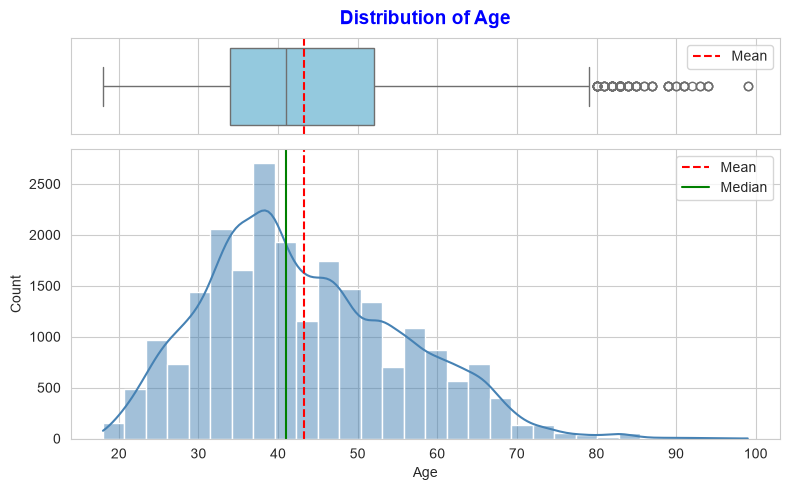

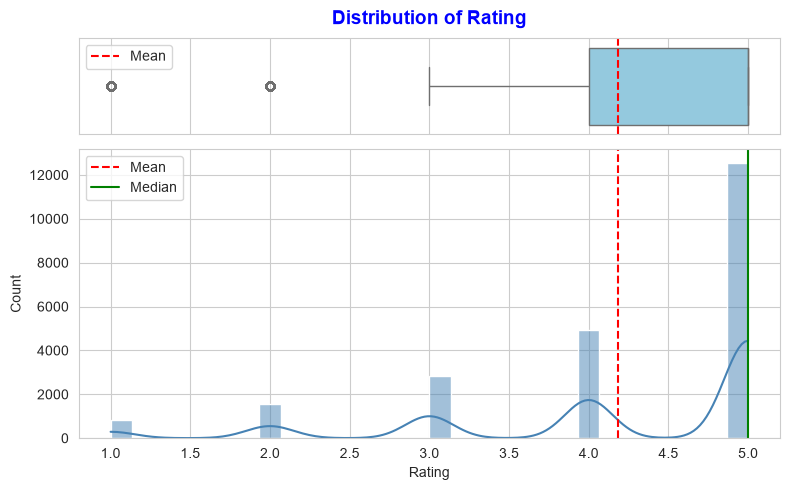

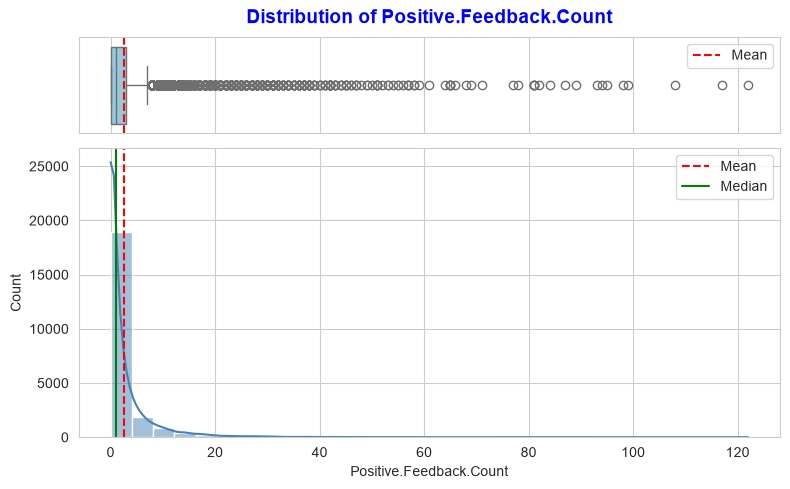

Observations:
   - Age: mean = 43.28, median = 41, range = 18 to 99. The distribution is fairly symmetric with most reviewers between 30 and 50.
   - Rating: mean = 4.18, median = 5, std = 1.12. Ratings cluster at 4 and 5, indicating predominantly positive feedback.
   - Positive.Feedback.Count: mean = 2.63, median = 1, max = 122. The variable is strongly right-skewed because most reviews receive very few helpful votes.


In [204]:
# ------------------------------------------------------------------
# Question 1: Summary statistics of numerical data
# ------------------------------------------------------------------
print("\nQuestion 1: Summary statistics of numerical data")
print("-" * 80)

# Summary table for all numeric fields.
display(df[numeric_eda_cols].describe())

# Focus on Age, Rating, and Positive.Feedback.Count with distribution plots.
for col in ["Age", "Rating", "Positive.Feedback.Count"]:
    histogram_boxplot(df, col)

print("Observations:")
print(f"   - Age: mean = {df['Age'].mean():.2f}, median = {df['Age'].median():.0f}, "
      f"range = {df['Age'].min()} to {df['Age'].max()}. The distribution is fairly symmetric with most reviewers between 30 and 50.")
print(f"   - Rating: mean = {df['Rating'].mean():.2f}, median = {df['Rating'].median():.0f}, "
      f"std = {df['Rating'].std():.2f}. Ratings cluster at 4 and 5, indicating predominantly positive feedback.")
print(f"   - Positive.Feedback.Count: mean = {df['Positive.Feedback.Count'].mean():.2f}, "
      f"median = {df['Positive.Feedback.Count'].median():.0f}, max = {df['Positive.Feedback.Count'].max()}. "
      f"The variable is strongly right-skewed because most reviews receive very few helpful votes.")


In [205]:
# ------------------------------------------------------------------
# Question 2: Unique values in categorical columns
# ------------------------------------------------------------------
print("\nQuestion 2: Unique values in categorical columns")
print("-" * 80)

unique_summary = pd.DataFrame({
    "unique_count": [df[col].nunique() for col in categorical_eda_cols],
    "top_value": [df[col].value_counts().idxmax() for col in categorical_eda_cols],
    "top_value_count": [df[col].value_counts().max() for col in categorical_eda_cols],
}, index=categorical_eda_cols)

display(unique_summary)

for col in categorical_eda_cols:
    print(f"\n{col} value counts:")
    display(df[col].value_counts(dropna=False).to_frame(name="count"))

print("Observations:")
print(f"   - Division.Name has {df['Division.Name'].nunique()} unique divisions; 'General' dominates the review volume.")
print(f"   - Department.Name has {df['Department.Name'].nunique()} unique departments; 'Tops' and 'Dresses' account for most reviews.")
print(f"   - Class.Name has {df['Class.Name'].nunique()} unique product classes, showing finer-grained product variation.")
print(f"   - A small number of rows still have missing category labels and should be handled in post-EDA cleaning.")



Question 2: Unique values in categorical columns
--------------------------------------------------------------------------------


,unique_count,top_value,top_value_count
Division.Name,3,General,13364
Department.Name,6,Tops,10048
Class.Name,20,Dresses,6145



Division.Name value counts:


,count
Division.Name,
General,13364
General Petite,7837
Initmates,1426
<NA>,13



Department.Name value counts:


,count
Department.Name,
Tops,10048
Dresses,6145
Bottoms,3661
Intimate,1653
Jackets,1002
Trend,118
<NA>,13



Class.Name value counts:


,count
Class.Name,
Dresses,6145
Knits,4626
Blouses,2983
Sweaters,1380
Pants,1350
Jeans,1103
Fine gauge,1059
Skirts,903
Jackets,683


Observations:
   - Division.Name has 3 unique divisions; 'General' dominates the review volume.
   - Department.Name has 6 unique departments; 'Tops' and 'Dresses' account for most reviews.
   - Class.Name has 20 unique product classes, showing finer-grained product variation.
   - A small number of rows still have missing category labels and should be handled in post-EDA cleaning.


In [206]:
# ------------------------------------------------------------------
# Question 3: Overall distribution of product Rating
# ------------------------------------------------------------------
print("\nQuestion 3: Overall distribution of product Rating")
print("-" * 80)

rating_counts = df["Rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(2)

display(pd.DataFrame({"count": rating_counts, "percentage": rating_pct}))

# Plotly histogram for interactive exploration of rating distribution.
fig_rating = px.histogram(
    df,
    x="Rating",
    color="Rating",
    title="Distribution of Product Ratings",
    category_orders={"Rating": [1, 2, 3, 4, 5]},
)
fig_rating.update_layout(
    xaxis_title="Rating (1-5)",
    yaxis_title="Number of Reviews",
)
fig_rating.show()

positive_share = ((df["Rating"] >= 4).sum() / len(df) * 100)
negative_share = ((df["Rating"] <= 2).sum() / len(df) * 100)

print("Observations:")
print(f"   - The dataset is strongly skewed toward positive reviews: {positive_share:.1f}% are 4-5 stars.")
print(f"   - Only {negative_share:.1f}% of reviews are 1-2 stars, so negative feedback is a smaller but important segment.")
print(f"   - The median rating is {df['Rating'].median():.0f} and the mean is {df['Rating'].mean():.2f}, confirming positive sentiment dominance.")
print(f"   - This imbalance should be considered when sampling reviews for LLM evaluation.")



Question 3: Overall distribution of product Rating
--------------------------------------------------------------------------------


,count,percentage
Rating,,
1,821,3.63
2,1549,6.84
3,2823,12.47
4,4908,21.68
5,12539,55.38


Observations:
   - The dataset is strongly skewed toward positive reviews: 77.1% are 4-5 stars.
   - Only 10.5% of reviews are 1-2 stars, so negative feedback is a smaller but important segment.
   - The median rating is 5 and the mean is 4.18, confirming positive sentiment dominance.
   - This imbalance should be considered when sampling reviews for LLM evaluation.


In [207]:
# ------------------------------------------------------------------
# Question 4: Average rating by Department Name
# ------------------------------------------------------------------
print("\nQuestion 4: Average rating by Department Name")
print("-" * 80)

avg_rating_by_dept = (
    df.groupby("Department.Name")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

display(avg_rating_by_dept)

highest_dept = avg_rating_by_dept.iloc[0]["Department.Name"]
lowest_dept = avg_rating_by_dept.iloc[-1]["Department.Name"]

fig_dept = px.bar(
    avg_rating_by_dept,
    x="mean",
    y="Department.Name",
    orientation="h",
    title="Average Customer Rating by Department",
    color="mean",
    text="mean",
)
fig_dept.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig_dept.update_layout(xaxis_title="Average Rating", yaxis_title="Department")
fig_dept.show()

print("Observations:")
print(f"   - Highest average rating: {highest_dept} ({avg_rating_by_dept.iloc[0]['mean']:.2f}).")
print(f"   - Lowest average rating: {lowest_dept} ({avg_rating_by_dept.iloc[-1]['mean']:.2f}).")
print(f"   - Differences between departments are modest because most ratings are 4-5 stars.")
print(f"   - Departments with lower averages may reflect fit, quality, or expectation issues rather than broad dissatisfaction.")



Question 4: Average rating by Department Name
--------------------------------------------------------------------------------


,Department.Name,mean,count
0,Bottoms,4.278612,3661
1,Intimate,4.271022,1653
2,Jackets,4.254491,1002
3,Tops,4.157743,10048
4,Dresses,4.138812,6145
5,Trend,3.838983,118


Observations:
   - Highest average rating: Bottoms (4.28).
   - Lowest average rating: Trend (3.84).
   - Differences between departments are modest because most ratings are 4-5 stars.
   - Departments with lower averages may reflect fit, quality, or expectation issues rather than broad dissatisfaction.



Question 5: Word clouds for positive vs negative reviews
--------------------------------------------------------------------------------
   - Positive review records (Rating >= 4): 17,447
   - Negative review records (Rating <= 2): 2,370


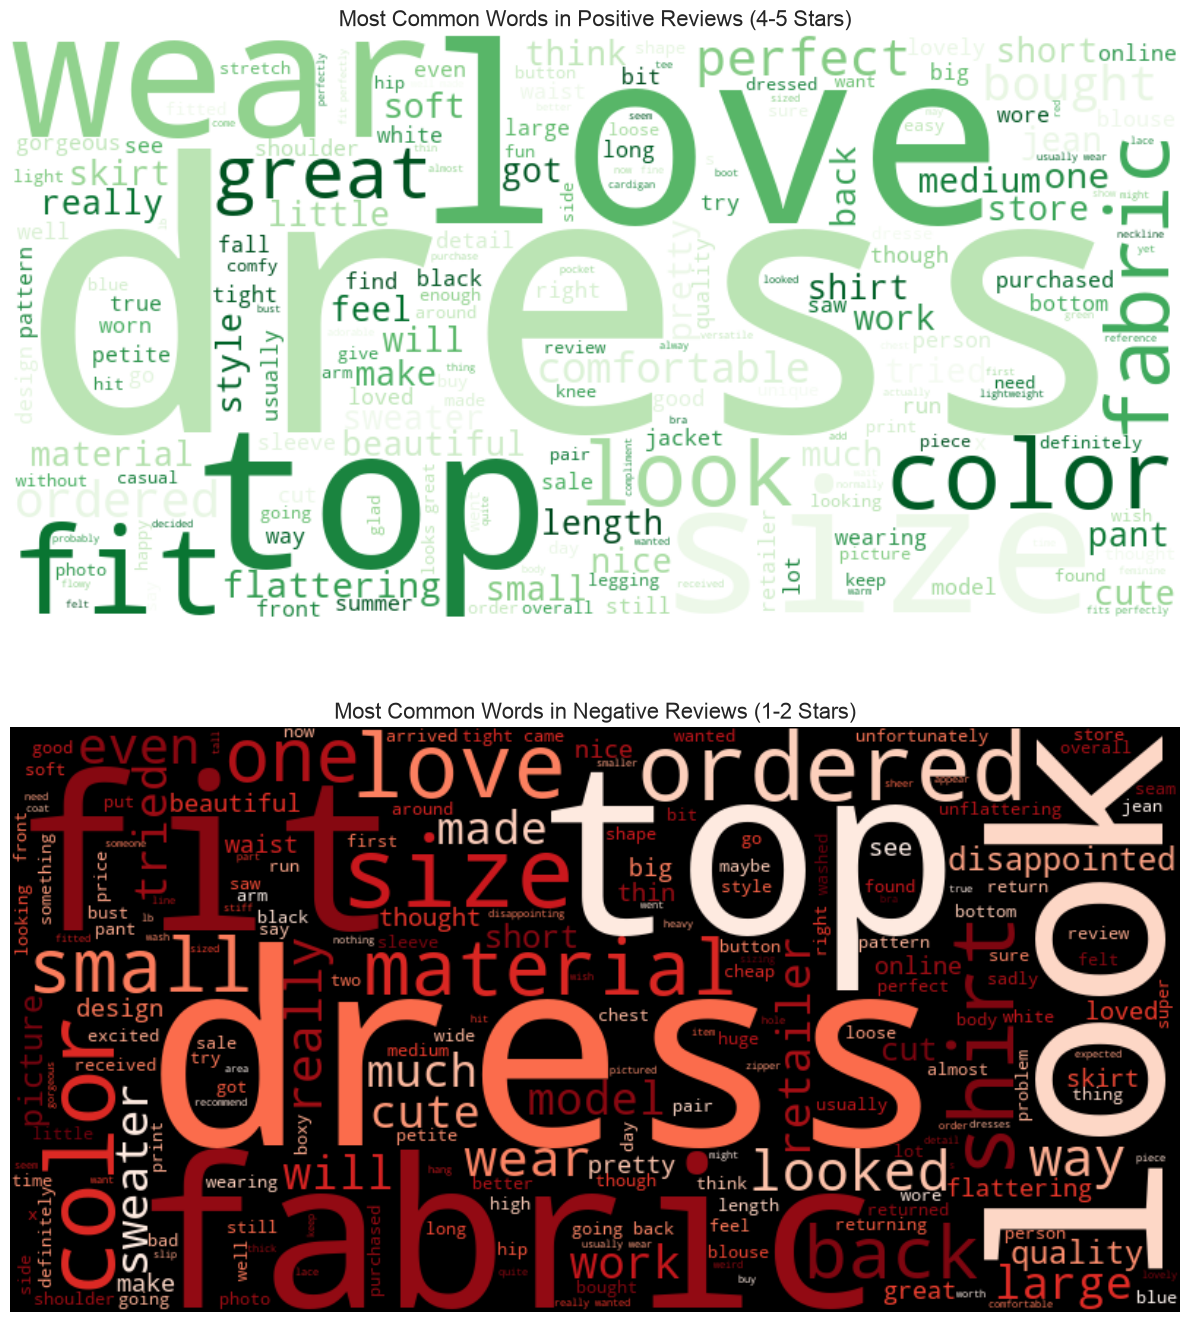

Observations:
   - Positive reviews frequently mention fit, fabric, color, comfort, and words like 'love' and 'perfect'.
   - Negative reviews emphasize sizing problems ('small', 'large', 'fit'), fabric quality, and returns/exchanges.
   - Fit and sizing appear to be the strongest shared theme across both satisfaction and dissatisfaction.
   - Initial hypothesis: improving size guidance and fit consistency could reduce negative reviews and strengthen loyalty.


In [208]:
# ------------------------------------------------------------------
# Question 5: Word clouds for high-rated vs low-rated reviews
# ------------------------------------------------------------------
print("\nQuestion 5: Word clouds for positive vs negative reviews")
print("-" * 80)

# Combine review text for each sentiment group.
positive_reviews = " ".join(df.loc[df["Rating"] >= 4, "Review.Text"].dropna().astype(str))
negative_reviews = " ".join(df.loc[df["Rating"] <= 2, "Review.Text"].dropna().astype(str))

print(f"   - Positive review records (Rating >= 4): {(df['Rating'] >= 4).sum():,}")
print(f"   - Negative review records (Rating <= 2): {(df['Rating'] <= 2).sum():,}")

# Generate word clouds to compare language patterns across sentiment groups.
wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens",
).generate(positive_reviews)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Reds",
).generate(negative_reviews)

# Stack word clouds vertically (positive on top, negative below) with spacing between them.
fig_wc, (ax_pos, ax_neg) = plt.subplots(2, 1, figsize=(12, 14))
fig_wc.subplots_adjust(hspace=0.35)

ax_pos.imshow(wordcloud_positive, interpolation="bilinear")
ax_pos.set_title("Most Common Words in Positive Reviews (4-5 Stars)", fontsize=16)
ax_pos.axis("off")

ax_neg.imshow(wordcloud_negative, interpolation="bilinear")
ax_neg.set_title("Most Common Words in Negative Reviews (1-2 Stars)", fontsize=16)
ax_neg.axis("off")

plt.tight_layout()
plt.show()

print("Observations:")
print("   - Positive reviews frequently mention fit, fabric, color, comfort, and words like 'love' and 'perfect'.")
print("   - Negative reviews emphasize sizing problems ('small', 'large', 'fit'), fabric quality, and returns/exchanges.")
print("   - Fit and sizing appear to be the strongest shared theme across both satisfaction and dissatisfaction.")
print("   - Initial hypothesis: improving size guidance and fit consistency could reduce negative reviews and strengthen loyalty.")


In [209]:
# ----------------------------------------------------------------------
# Additional Exploratory Data Analysis
# Supplementary analyses beyond the five core EDA questions.
# ----------------------------------------------------------------------

print("\n" + "=" * 80)
print("ADDITIONAL EDA ANALYSES")
print("=" * 80)



ADDITIONAL EDA ANALYSES



Additional Analysis 1: Rating vs. Recommended.IND consistency
--------------------------------------------------------------------------------


Recommended.IND,0,1,Total
Rating,,,
1,806,15,821
2,1455,94,1549
3,1653,1170,2823
4,164,4744,4908
5,23,12516,12539
Total,4101,18539,22640


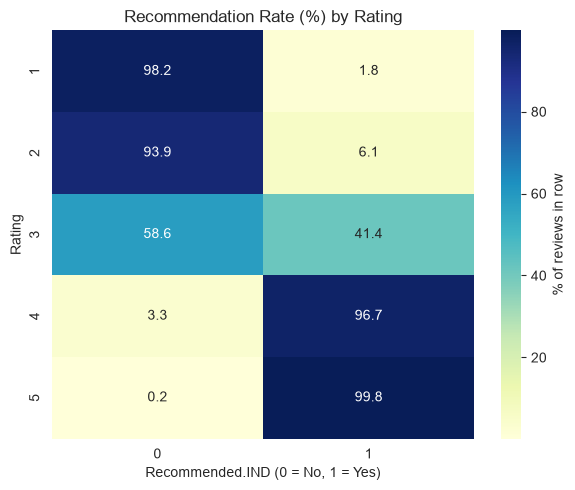

Observations:
   - Overall recommendation rate: 81.9% of reviews recommend the product.
   - At 5-star rating, 99.8% of reviewers still recommend the product (near-universal alignment).
   - 187 reviews have Rating >= 4 but Recommended.IND = 0 (qualified praise without recommendation).
   - 109 reviews have Rating <= 2 but Recommended.IND = 1 (rare conflicting signals worth manual review).
   - Rating and Recommended.IND are strongly aligned; mismatches are a small but actionable subset for the LLM pipeline.


In [210]:
# ------------------------------------------------------------------
# Additional Analysis 1: Rating vs. Recommended.IND consistency
# Compare star ratings with the binary recommendation flag to identify aligned vs. conflicting satisfaction signals.
# ------------------------------------------------------------------
print("\nAdditional Analysis 1: Rating vs. Recommended.IND consistency")
print("-" * 80)

rating_rec_crosstab = pd.crosstab(
    df["Rating"], df["Recommended.IND"], margins=True, margins_name="Total"
)
display(rating_rec_crosstab)

crosstab_pct = pd.crosstab(df["Rating"], df["Recommended.IND"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    crosstab_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "% of reviews in row"},
    ax=ax,
)
ax.set_title("Recommendation Rate (%) by Rating")
ax.set_xlabel("Recommended.IND (0 = No, 1 = Yes)")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show()

mismatch_high = ((df["Rating"] >= 4) & (df["Recommended.IND"] == 0)).sum()
mismatch_low = ((df["Rating"] <= 2) & (df["Recommended.IND"] == 1)).sum()
pct_recommend_at_5 = crosstab_pct.loc[5, 1] if 5 in crosstab_pct.index else np.nan

print("Observations:")
print(f"   - Overall recommendation rate: {df['Recommended.IND'].mean() * 100:.1f}% of reviews recommend the product.")
print(f"   - At 5-star rating, {pct_recommend_at_5:.1f}% of reviewers still recommend the product (near-universal alignment).")
print(f"   - {mismatch_high:,} reviews have Rating >= 4 but Recommended.IND = 0 (qualified praise without recommendation).")
print(f"   - {mismatch_low:,} reviews have Rating <= 2 but Recommended.IND = 1 (rare conflicting signals worth manual review).")
print(f"   - Rating and Recommended.IND are strongly aligned; mismatches are a small but actionable subset for the LLM pipeline.")



Additional Analysis 2: Rating and recommendation by Class and Division
--------------------------------------------------------------------------------
Class.Name summary:


,Class.Name,review_count,mean_rating,recommend_rate,recommend_pct
0,Layering,132,4.348485,0.878788,87.878788
1,Jeans,1103,4.347235,0.87942,87.941976
2,Lounge,669,4.301943,0.857997,85.799701
3,Sleep,214,4.294393,0.85514,85.514019
4,Jackets,683,4.288433,0.843338,84.333821
5,Intimates,147,4.278912,0.857143,85.714286
6,Pants,1350,4.261481,0.832593,83.259259
7,Shorts,304,4.253289,0.838816,83.881579
8,Legwear,158,4.246835,0.85443,85.443038
9,Fine gauge,1059,4.23796,0.832861,83.286119


Division.Name summary:


,Division.Name,review_count,mean_rating,recommend_rate,recommend_pct
0,Initmates,1426,4.275596,0.847826,84.782609
1,General Petite,7837,4.196631,0.822509,82.250861
2,General,13364,4.16522,0.813454,81.345406


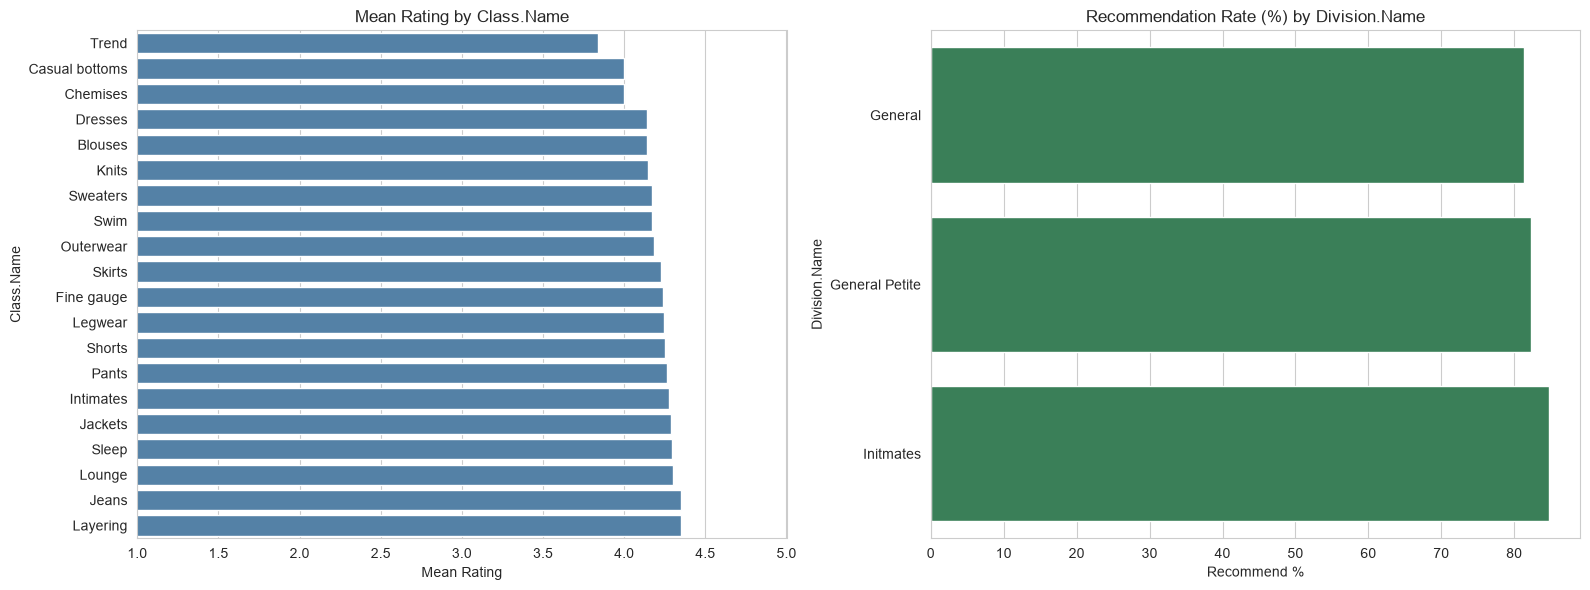

Observations:
   - Class.Name has 20 categories; Division.Name has 3 divisions.
   - Highest-rated class: Layering (mean rating = 4.35, n = 132).
   - Lowest-rated class: Trend (mean rating = 3.84, n = 118).
   - Lowest recommendation rate by division: General (81.3% recommend).
   - Class-level breakdowns reveal category-specific issues that department averages may mask.


In [211]:
# ------------------------------------------------------------------
# Additional Analysis 2: Recommendation rate and rating by Class.Name and Division.Name
# Extend department-level insights to division and class to pinpoint granular product categories with satisfaction gaps.
# ------------------------------------------------------------------
print("\nAdditional Analysis 2: Rating and recommendation by Class and Division")
print("-" * 80)

def category_satisfaction_summary(group_col):
    summary = (
        df.groupby(group_col)
        .agg(
            review_count=("Rating", "count"),
            mean_rating=("Rating", "mean"),
            recommend_rate=("Recommended.IND", "mean"),
        )
        .assign(recommend_pct=lambda x: x["recommend_rate"] * 100)
        .sort_values("mean_rating", ascending=False)
        .reset_index()
    )
    return summary

class_summary = category_satisfaction_summary("Class.Name")
division_summary = category_satisfaction_summary("Division.Name")

print("Class.Name summary:")
display(class_summary)

print("Division.Name summary:")
display(division_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=class_summary.sort_values("mean_rating", ascending=True),
    y="Class.Name",
    x="mean_rating",
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Mean Rating by Class.Name")
axes[0].set_xlabel("Mean Rating")
axes[0].set_xlim(1, 5)

sns.barplot(
    data=division_summary.sort_values("recommend_pct", ascending=True),
    y="Division.Name",
    x="recommend_pct",
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title("Recommendation Rate (%) by Division.Name")
axes[1].set_xlabel("Recommend %")
plt.tight_layout()
plt.show()

lowest_class = class_summary.iloc[-1]
highest_class = class_summary.iloc[0]
lowest_div = division_summary.iloc[-1]

print("Observations:")
print(f"   - Class.Name has {class_summary['Class.Name'].nunique()} categories; Division.Name has {division_summary['Division.Name'].nunique()} divisions.")
print(f"   - Highest-rated class: {highest_class['Class.Name']} (mean rating = {highest_class['mean_rating']:.2f}, n = {int(highest_class['review_count']):,}).")
print(f"   - Lowest-rated class: {lowest_class['Class.Name']} (mean rating = {lowest_class['mean_rating']:.2f}, n = {int(lowest_class['review_count']):,}).")
print(f"   - Lowest recommendation rate by division: {lowest_div['Division.Name']} ({lowest_div['recommend_pct']:.1f}% recommend).")
print(f"   - Class-level breakdowns reveal category-specific issues that department averages may mask.")



Additional Analysis 3: Product-level risk (Clothing.ID)
--------------------------------------------------------------------------------
Products with at least 10 reviews: 228 of 1,179 total products


,Clothing.ID,review_count,mean_rating,recommend_rate
218,229,11,2.181818,0.272727
905,929,19,3.105263,0.526316
860,884,11,3.181818,0.636364
924,948,10,3.2,0.5
1030,1055,24,3.291667,0.541667
992,1016,24,3.333333,0.625
962,986,31,3.419355,0.612903
1059,1084,72,3.458333,0.708333
462,482,10,3.5,0.4
818,841,25,3.52,0.6


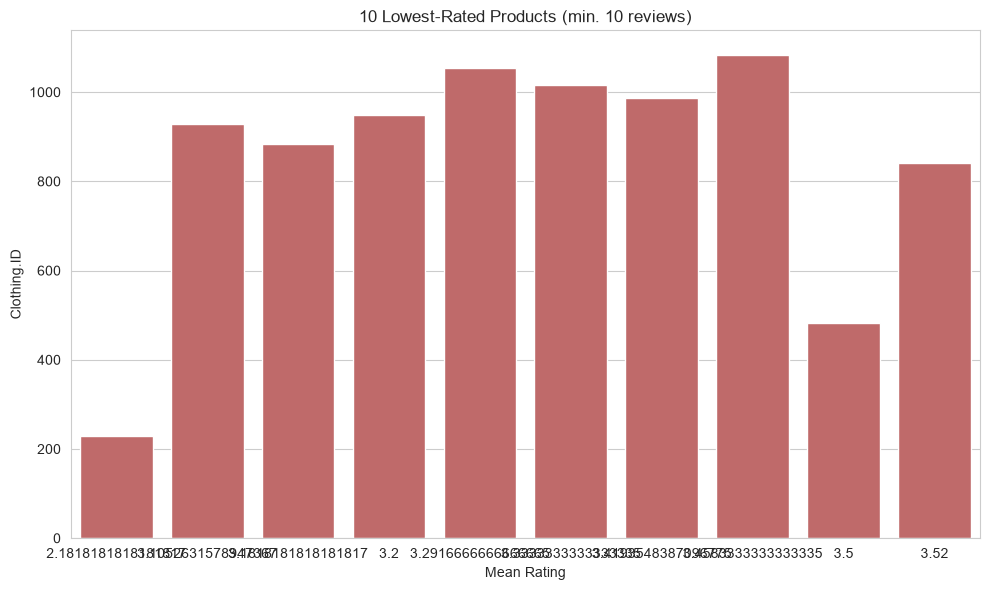

Observations:
   - 1,179 unique Clothing.ID values appear in the dataset.
   - Worst-rated product (min. 10 reviews): ID 229 (mean rating = 2.18, n = 11).
   - Best-rated product (min. 10 reviews): ID 252 (mean rating = 4.82, n = 11).
   - Product-level monitoring complements category averages and supports targeted interventions during peak seasons.


In [212]:
# ------------------------------------------------------------------
# Additional Analysis 3: Product-level risk — worst-rated items (Clothing.ID)
# Flag individual products with persistently low ratings so the retail team can investigate defects, sizing, or listing issues.
# ------------------------------------------------------------------
print("\nAdditional Analysis 3: Product-level risk (Clothing.ID)")
print("-" * 80)

MIN_REVIEWS = 10

product_stats = (
    df.groupby("Clothing.ID")
    .agg(
        review_count=("Rating", "count"),
        mean_rating=("Rating", "mean"),
        recommend_rate=("Recommended.IND", "mean"),
    )
    .reset_index()
)

reliable_products = product_stats[product_stats["review_count"] >= MIN_REVIEWS].copy()
worst_rated = reliable_products.nsmallest(10, "mean_rating")
best_rated = reliable_products.nlargest(10, "mean_rating")

print(f"Products with at least {MIN_REVIEWS} reviews: {len(reliable_products):,} of {product_stats['Clothing.ID'].nunique():,} total products")
display(worst_rated.sort_values("mean_rating"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=worst_rated.sort_values("mean_rating", ascending=False),
    y="Clothing.ID",
    x="mean_rating",
    ax=ax,
    color="indianred",
)
ax.set_title(f"10 Lowest-Rated Products (min. {MIN_REVIEWS} reviews)")
ax.set_xlabel("Mean Rating")
ax.set_ylabel("Clothing.ID")
plt.tight_layout()
plt.show()

print("Observations:")
print(f"   - {product_stats['Clothing.ID'].nunique():,} unique Clothing.ID values appear in the dataset.")
print(f"   - Worst-rated product (min. {MIN_REVIEWS} reviews): ID {worst_rated.iloc[0]['Clothing.ID']:.0f} "
      f"(mean rating = {worst_rated.iloc[0]['mean_rating']:.2f}, n = {int(worst_rated.iloc[0]['review_count']):,}).")
print(f"   - Best-rated product (min. {MIN_REVIEWS} reviews): ID {best_rated.iloc[0]['Clothing.ID']:.0f} "
      f"(mean rating = {best_rated.iloc[0]['mean_rating']:.2f}, n = {int(best_rated.iloc[0]['review_count']):,}).")
print(f"   - Product-level monitoring complements category averages and supports targeted interventions during peak seasons.")



Additional Analysis 4: Review text length by rating
--------------------------------------------------------------------------------


,count,mean,median,max
Rating,,,,
1,821,58.6,57.0,111
2,1549,62.1,62.0,110
3,2823,64.2,64.0,115
4,4908,63.3,64.0,113
5,12539,57.9,56.0,115


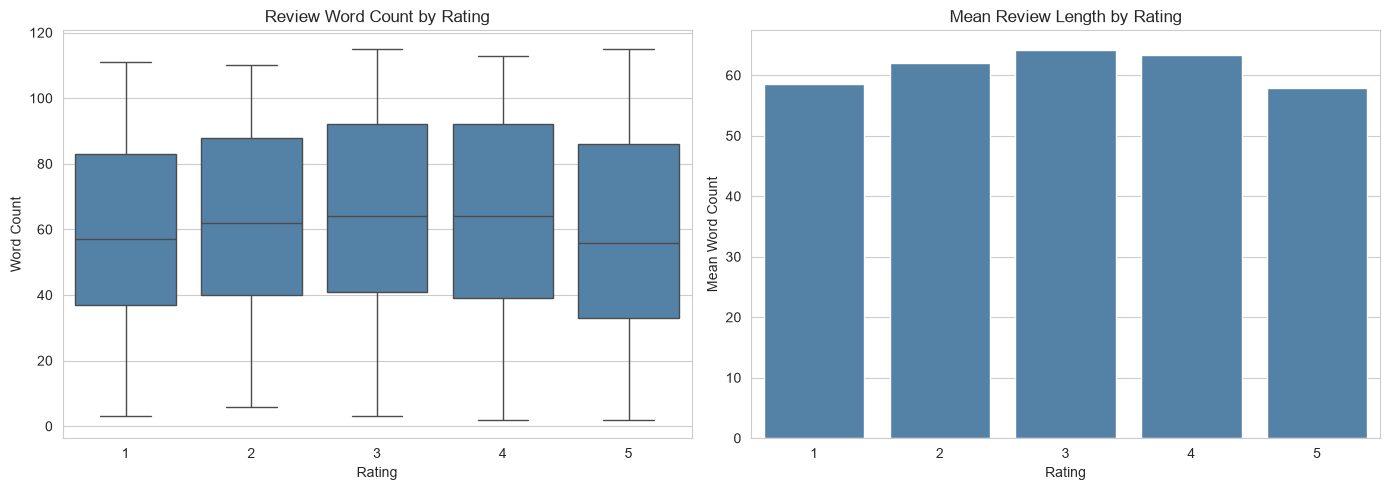

Observations:
   - Overall mean review length: 60.2 words; median = 59.
   - Longest average reviews occur at rating 3 (64.2 words on average).
   - Shortest average reviews occur at rating 5 (57.9 words on average).
   - Review length varies modestly across ratings; the LLM pipeline should handle both brief and detailed feedback.


In [213]:
# ------------------------------------------------------------------
# Additional Analysis 4: Review text length by rating
# Understand how much text customers write at each rating level, which informs GenAI input length and urgency triage rules.
# ------------------------------------------------------------------
print("\nAdditional Analysis 4: Review text length by rating")
print("-" * 80)

df_eda = df.copy()
df_eda["review_word_count"] = df_eda["Review.Text"].astype(str).str.split().str.len()

length_summary = (
    df_eda.groupby("Rating")["review_word_count"]
    .agg(["count", "mean", "median", "max"])
    .round(1)
)
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_eda, x="Rating", y="review_word_count", ax=axes[0], color="steelblue")
axes[0].set_title("Review Word Count by Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Word Count")

sns.barplot(
    data=length_summary.reset_index(),
    x="Rating",
    y="mean",
    ax=axes[1],
    color="steelblue",
)
axes[1].set_title("Mean Review Length by Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Mean Word Count")
plt.tight_layout()
plt.show()

longest_rating = length_summary["mean"].idxmax()
shortest_rating = length_summary["mean"].idxmin()

print("Observations:")
print(f"   - Overall mean review length: {df_eda['review_word_count'].mean():.1f} words; median = {df_eda['review_word_count'].median():.0f}.")
print(f"   - Longest average reviews occur at rating {longest_rating} ({length_summary.loc[longest_rating, 'mean']:.1f} words on average).")
print(f"   - Shortest average reviews occur at rating {shortest_rating} ({length_summary.loc[shortest_rating, 'mean']:.1f} words on average).")
print(f"   - Review length varies modestly across ratings; the LLM pipeline should handle both brief and detailed feedback.")



Additional Analysis 5: Numeric correlation heatmap
--------------------------------------------------------------------------------


,Age,Rating,Positive.Feedback.Count,Recommended.IND
Age,1.000,0.030,0.041,0.034
Rating,0.030,1.000,-0.061,0.793
Positive.Feedback.Count,0.041,-0.061,1.000,-0.066
Recommended.IND,0.034,0.793,-0.066,1.000


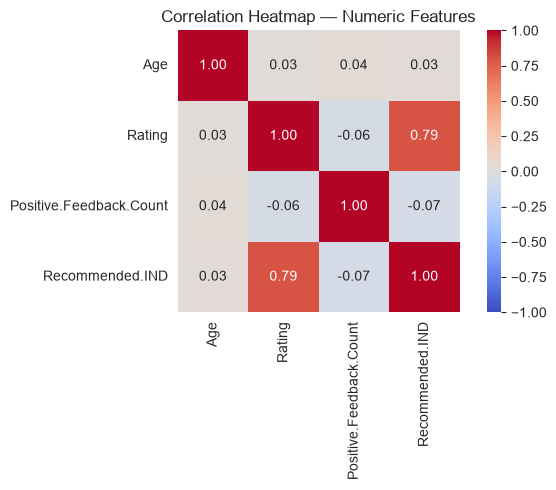

Observations:
   - Strongest correlation with Rating: Recommended.IND (r = 0.79).
   - Rating vs. Positive.Feedback.Count: r = -0.06 (slightly more helpful votes on lower-rated reviews).
   - Age vs. Rating: r = 0.03 (demographics have limited linear association with scores).
   - No numeric pair shows problematic multicollinearity for downstream analysis.


In [214]:
# ------------------------------------------------------------------
# Additional Analysis 5: Numeric correlation heatmap
# Examine linear relationships among numeric fields to guide feature understanding before modeling or GenAI evaluation.
# ------------------------------------------------------------------
print("\nAdditional Analysis 5: Numeric correlation heatmap")
print("-" * 80)

corr_matrix = df[numeric_eda_cols].corr().round(3)
display(corr_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

rating_rec_corr = corr_matrix.loc["Rating", "Recommended.IND"]
rating_feedback_corr = corr_matrix.loc["Rating", "Positive.Feedback.Count"]
age_rating_corr = corr_matrix.loc["Age", "Rating"]

print("Observations:")
print(f"   - Strongest correlation with Rating: Recommended.IND (r = {rating_rec_corr:.2f}).")
print(f"   - Rating vs. Positive.Feedback.Count: r = {rating_feedback_corr:.2f} (slightly more helpful votes on lower-rated reviews).")
print(f"   - Age vs. Rating: r = {age_rating_corr:.2f} (demographics have limited linear association with scores).")
print(f"   - No numeric pair shows problematic multicollinearity for downstream analysis.")



Additional Analysis 6: Positive.Feedback.Count vs. rating
--------------------------------------------------------------------------------


,count,mean,median,max
Rating,,,,
1,821,3.55,1.0,108
2,1549,3.36,1.0,65
3,2823,3.2,1.0,122
4,4908,2.49,1.0,95
5,12539,2.41,1.0,117


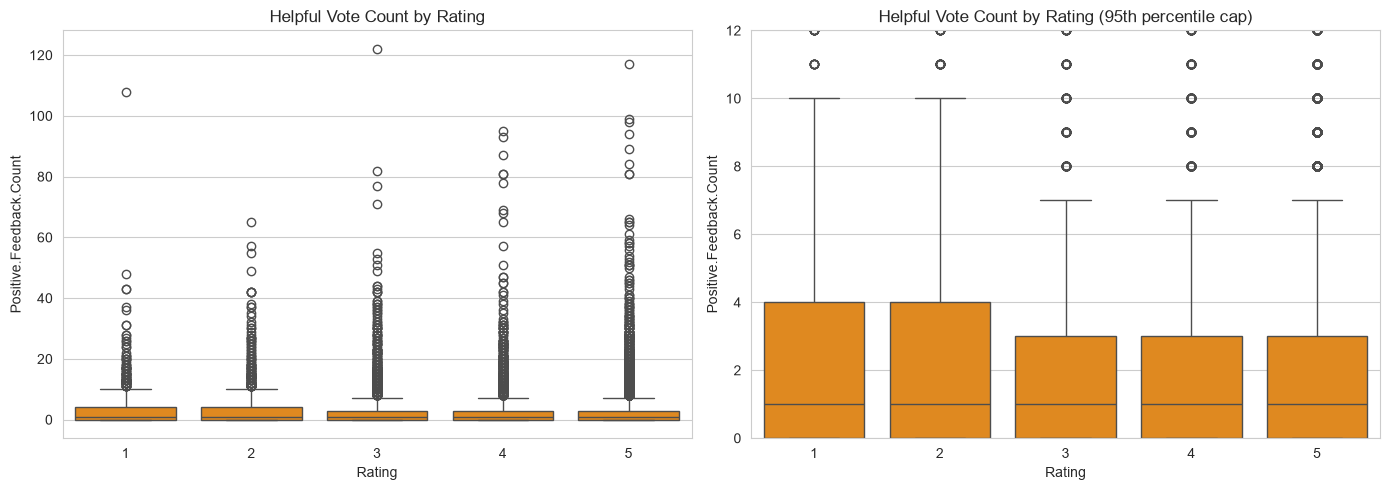

Observations:
   - 45.6% of reviews have zero helpful votes (right-skewed engagement).
   - Highest mean helpful votes by rating: 1 stars (mean = 3.55).
   - Maximum helpful votes on a single review: 122 (outlier engagement).
   - Helpful votes are weakly tied to rating; highly-voted negative reviews may signal widespread product issues.


In [215]:
# ------------------------------------------------------------------
# Additional Analysis 6: Positive.Feedback.Count vs. rating
# See whether low-rated reviews attract more 'helpful' votes, indicating issues many customers agree with.
# ------------------------------------------------------------------
print("\nAdditional Analysis 6: Positive.Feedback.Count vs. rating")
print("-" * 80)

feedback_by_rating = (
    df.groupby("Rating")["Positive.Feedback.Count"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)
display(feedback_by_rating)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Rating", y="Positive.Feedback.Count", ax=axes[0], color="darkorange")
axes[0].set_title("Helpful Vote Count by Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Positive.Feedback.Count")

cap = df["Positive.Feedback.Count"].quantile(0.95)
sns.boxplot(data=df, x="Rating", y="Positive.Feedback.Count", ax=axes[1], color="darkorange")
axes[1].set_ylim(0, cap)
axes[1].set_title("Helpful Vote Count by Rating (95th percentile cap)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Positive.Feedback.Count")
plt.tight_layout()
plt.show()

top_feedback_rating = feedback_by_rating["mean"].idxmax()
zero_feedback_pct = (df["Positive.Feedback.Count"] == 0).mean() * 100

print("Observations:")
print(f"   - {zero_feedback_pct:.1f}% of reviews have zero helpful votes (right-skewed engagement).")
print(f"   - Highest mean helpful votes by rating: {top_feedback_rating} stars "
      f"(mean = {feedback_by_rating.loc[top_feedback_rating, 'mean']:.2f}).")
print(f"   - Maximum helpful votes on a single review: {df['Positive.Feedback.Count'].max()} (outlier engagement).")
print(f"   - Helpful votes are weakly tied to rating; highly-voted negative reviews may signal widespread product issues.")



Additional Analysis 7: Age segments vs. satisfaction
--------------------------------------------------------------------------------


,age_segment,review_count,mean_rating,recommend_rate,recommend_pct
0,18-30,3221,4.180689,0.809686,80.968643
1,31-45,10551,4.157047,0.809876,80.987584
2,46-60,6484,4.190469,0.825879,82.587909
3,61+,2384,4.285654,0.85193,85.192953


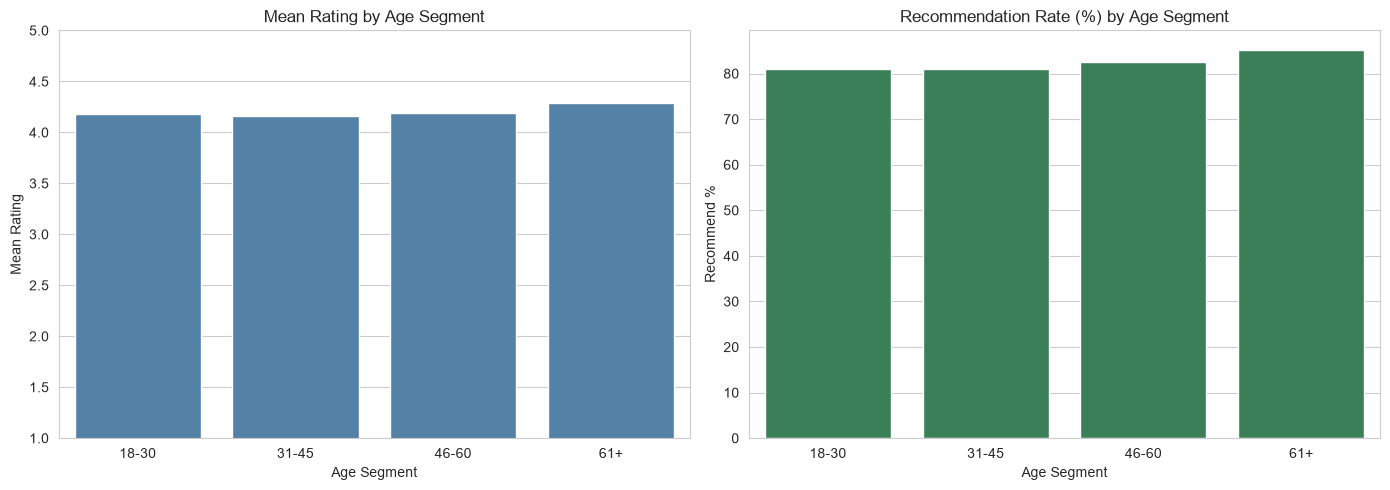

Observations:
   - Largest age segment by volume: 31-45 (10,551 reviews).
   - Highest mean rating: 61+ (mean = 4.29).
   - Lowest mean rating: 31-45 (mean = 4.16).
   - Age segments show modest differences in satisfaction; product and fit issues dominate over demographics.


In [216]:
# ------------------------------------------------------------------
# Additional Analysis 7: Age segments vs. satisfaction
# Compare satisfaction across reviewer age groups for targeted messaging, sizing guidance, and service recovery strategies.
# ------------------------------------------------------------------
print("\nAdditional Analysis 7: Age segments vs. satisfaction")
print("-" * 80)

df_age = df.copy()
df_age["age_segment"] = pd.cut(
    df_age["Age"],
    bins=[17, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "61+"],
)

age_summary = (
    df_age.groupby("age_segment", observed=True)
    .agg(
        review_count=("Rating", "count"),
        mean_rating=("Rating", "mean"),
        recommend_rate=("Recommended.IND", "mean"),
    )
    .assign(recommend_pct=lambda x: x["recommend_rate"] * 100)
    .reset_index()
)
display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=age_summary, x="age_segment", y="mean_rating", ax=axes[0], color="steelblue")
axes[0].set_title("Mean Rating by Age Segment")
axes[0].set_xlabel("Age Segment")
axes[0].set_ylabel("Mean Rating")
axes[0].set_ylim(1, 5)

sns.barplot(data=age_summary, x="age_segment", y="recommend_pct", ax=axes[1], color="seagreen")
axes[1].set_title("Recommendation Rate (%) by Age Segment")
axes[1].set_xlabel("Age Segment")
axes[1].set_ylabel("Recommend %")
plt.tight_layout()
plt.show()

highest_age = age_summary.loc[age_summary["mean_rating"].idxmax()]
lowest_age = age_summary.loc[age_summary["mean_rating"].idxmin()]

print("Observations:")
print(f"   - Largest age segment by volume: {age_summary.loc[age_summary['review_count'].idxmax(), 'age_segment']} "
      f"({int(age_summary['review_count'].max()):,} reviews).")
print(f"   - Highest mean rating: {highest_age['age_segment']} (mean = {highest_age['mean_rating']:.2f}).")
print(f"   - Lowest mean rating: {lowest_age['age_segment']} (mean = {lowest_age['mean_rating']:.2f}).")
print(f"   - Age segments show modest differences in satisfaction; product and fit issues dominate over demographics.")



Additional Analysis 8: Review volume concentration
--------------------------------------------------------------------------------


,Clothing.ID,review_count,cumulative_pct
0,1078,987,4.359541
1,862,778,7.795936
2,1094,735,11.042403
3,1081,561,13.520318
4,872,519,15.812721
5,829,512,18.074205
6,1110,471,20.154594
7,868,414,21.983216
8,895,384,23.679329
9,936,348,25.216431


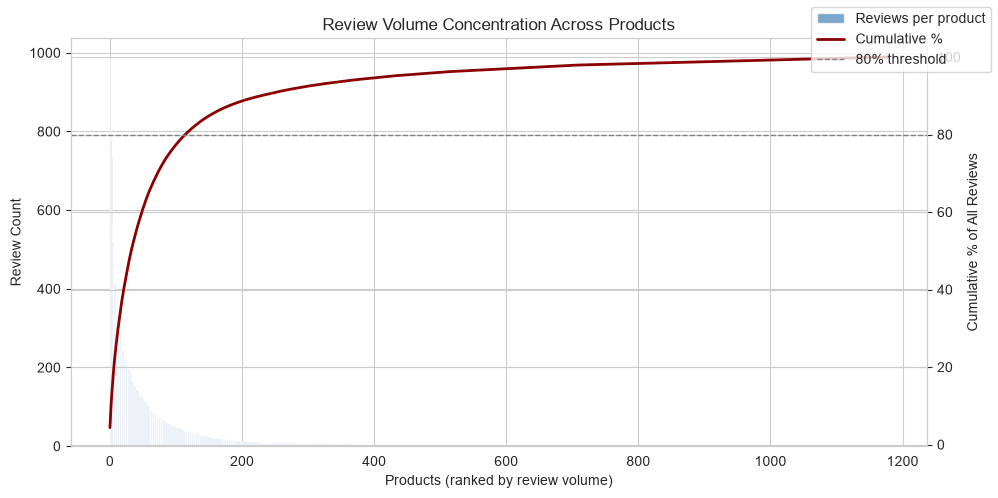

Observations:
   - 1,179 products received at least one review.
   - Top 10 products account for 25.2% of all reviews.
   - Approximately 115 products (~9.8% of catalog) drive 80% of review volume.
   - Monitoring high-volume SKUs during peak seasons yields disproportionate impact on customer perception.


In [217]:
# ------------------------------------------------------------------
# Additional Analysis 8: Review volume concentration (Pareto view)
# Check whether feedback is concentrated on a few products, which matters for prioritization during high-volume sales periods.
# ------------------------------------------------------------------
print("\nAdditional Analysis 8: Review volume concentration")
print("-" * 80)

volume_by_product = (
    df.groupby("Clothing.ID")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="review_count")
)
volume_by_product["cumulative_pct"] = (
    volume_by_product["review_count"].cumsum() / volume_by_product["review_count"].sum() * 100
)

top_n = 10
top_share = volume_by_product.head(top_n)["review_count"].sum() / volume_by_product["review_count"].sum() * 100
products_for_80pct = (volume_by_product["cumulative_pct"] <= 80).sum() + 1

display(volume_by_product.head(15))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = range(len(volume_by_product))
ax1.bar(x, volume_by_product["review_count"], color="steelblue", alpha=0.7, label="Reviews per product")
ax2.plot(x, volume_by_product["cumulative_pct"], color="darkred", linewidth=2, label="Cumulative %")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1, label="80% threshold")

ax1.set_xlabel("Products (ranked by review volume)")
ax1.set_ylabel("Review Count")
ax2.set_ylabel("Cumulative % of All Reviews")
ax1.set_title("Review Volume Concentration Across Products")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Observations:")
print(f"   - {volume_by_product['Clothing.ID'].nunique():,} products received at least one review.")
print(f"   - Top {top_n} products account for {top_share:.1f}% of all reviews.")
print(f"   - Approximately {products_for_80pct} products (~{products_for_80pct / volume_by_product['Clothing.ID'].nunique() * 100:.1f}% of catalog) drive 80% of review volume.")
print(f"   - Monitoring high-volume SKUs during peak seasons yields disproportionate impact on customer perception.")


In [218]:
# ------------------------------------------------------------------
# Additional Analysis 9: Bigram and trigram comparison (beyond word clouds)
# Purpose: Surface multi-word phrases (e.g., sizing complaints) that
#          single-word clouds miss, guiding root-cause and prompt design.
# ------------------------------------------------------------------
print("\nAdditional Analysis 9: Bigram and trigram comparison")
print("-" * 80)

from sklearn.feature_extraction.text import CountVectorizer

positive_text = df.loc[df["Rating"] >= 4, "Review.Text"].dropna().astype(str)
negative_text = df.loc[df["Rating"] <= 2, "Review.Text"].dropna().astype(str)


def top_ngrams(corpus, ngram_range, top_n=15):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words="english", min_df=5)
    matrix = vectorizer.fit_transform(corpus)
    counts = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    ranking = pd.Series(counts, index=terms).sort_values(ascending=False).head(top_n)
    return ranking


pos_bigrams = top_ngrams(positive_text, (2, 2))
neg_bigrams = top_ngrams(negative_text, (2, 2))
pos_trigrams = top_ngrams(positive_text, (3, 3))
neg_trigrams = top_ngrams(negative_text, (3, 3))

print("Top bigrams — positive reviews (Rating >= 4):")
display(pos_bigrams.to_frame(name="count"))

print("Top bigrams — negative reviews (Rating <= 2):")
display(neg_bigrams.to_frame(name="count"))

print("Top trigrams — positive reviews (Rating >= 4):")
display(pos_trigrams.to_frame(name="count"))

print("Top trigrams — negative reviews (Rating <= 2):")
display(neg_trigrams.to_frame(name="count"))

print("Observations:")
print(f"   - Top positive bigram: '{pos_bigrams.index[0]}' ({int(pos_bigrams.iloc[0]):,} occurrences).")
print(f"   - Top negative bigram: '{neg_bigrams.index[0]}' ({int(neg_bigrams.iloc[0]):,} occurrences).")
print(f"   - Positive trigrams often reflect fit satisfaction (e.g., '{pos_trigrams.index[0]}').")
print(f"   - Negative trigrams highlight sizing and quality phrases (e.g., '{neg_trigrams.index[0]}').")
print(f"   - Phrase-level analysis confirms fit/sizing as the dominant theme for both satisfaction and dissatisfaction.")

print("\n" + "=" * 80)
print("EDA COMPLETE")
print("=" * 80)



Additional Analysis 9: Bigram and trigram comparison
--------------------------------------------------------------------------------
Top bigrams — positive reviews (Rating >= 4):


,count
true size,1203
love dress,649
looks great,571
usually wear,551
fit perfectly,538
fits perfectly,477
size small,427
just right,400
usual size,393
highly recommend,362


Top bigrams — negative reviews (Rating <= 2):


,count
looked like,135
looks like,127
wanted love,125
look like,84
really wanted,81
felt like,68
usually wear,66
size small,55
didn work,55
true size,51


Top trigrams — positive reviews (Rating >= 4):


,count
fits true size,265
fit true size,193
runs true size,138
love love love,135
usually wear size,111
does run large,87
ordered usual size,79
small fit perfectly,72
looks great jeans,69
fits like glove,65


Top trigrams — negative reviews (Rating <= 2):


,count
really wanted love,40
really wanted like,28
wanted love dress,24
fit true size,18
ordered usual size,16
just didn work,16
usually wear size,16
looked like wearing,14
felt like wearing,12
looked like maternity,11


Observations:
   - Top positive bigram: 'true size' (1,203 occurrences).
   - Top negative bigram: 'looked like' (135 occurrences).
   - Positive trigrams often reflect fit satisfaction (e.g., 'fits true size').
   - Negative trigrams highlight sizing and quality phrases (e.g., 'really wanted love').
   - Phrase-level analysis confirms fit/sizing as the dominant theme for both satisfaction and dissatisfaction.

EDA COMPLETE


### **Deep Cleaning & Preprocessing (After EDA)**

In [219]:
# ----------------------------------------------------------------------
# Data Cleaning and Preprocessing - Deep Cleaning & Preprocessing (After EDA)
# Goal: prepare a modeling-ready dataset while preserving Review.Text for GenAI.
# Items Identified in EDA:
# - Title is missing in ~13% of rows but Review.Text is complete -> impute Title.
# - 13 rows missing category labels -> impute as "Unknown" (too few to drop).
# - Positive.Feedback.Count is right-skewed (max 122, median 1) -> cap extreme values.
# - Categorical hierarchy (Division / Department / Class) -> one-hot encode.
# - Age and helpful-vote counts -> standard-scale for downstream ML features.
# ----------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

rows_before_deep = df.shape[0]

print("=" * 80)
print("DEEP CLEANING & PREPROCESSING (AFTER EDA)")
print("=" * 80)
print(f"Starting shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Work on a copy so pre-deep-cleaning data can still be referenced if needed.
df_deep = df.copy()


DEEP CLEANING & PREPROCESSING (AFTER EDA)
Starting shape: 22,640 rows x 10 columns


In [220]:
# ------------------------------------------------------------------
# 1. Missing value analysis and treatment
# ------------------------------------------------------------------
print("\n1. Missing Value Treatment")
print("-" * 80)

missing_before = df_deep.isna().sum()
missing_before = missing_before[missing_before > 0]
print("Missing values before deep cleaning:")
display(missing_before.to_frame(name="missing_count"))

# Title: optional metadata; Review.Text is present for all rows -> impute placeholder.
title_missing = df_deep["Title"].isna().sum()
df_deep["Title"] = df_deep["Title"].fillna("No Title")
print(f"   - Title: imputed {title_missing:,} missing values with 'No Title' (Review.Text retained for analysis).")

# Category hierarchy: only 13 rows affected -> impute rather than drop usable reviews.
category_cols = ["Division.Name", "Department.Name", "Class.Name"]
for col in category_cols:
    cat_missing = df_deep[col].isna().sum()
    df_deep[col] = df_deep[col].fillna("Unknown")
    print(f"   - {col}: imputed {cat_missing:,} missing values with 'Unknown'.")

missing_after = df_deep.isna().sum().sum()
print(f"   - Total missing values after imputation: {missing_after:,}")



1. Missing Value Treatment
--------------------------------------------------------------------------------
Missing values before deep cleaning:


,missing_count
Title,2965
Division.Name,13
Department.Name,13
Class.Name,13


   - Title: imputed 2,965 missing values with 'No Title' (Review.Text retained for analysis).
   - Division.Name: imputed 13 missing values with 'Unknown'.
   - Department.Name: imputed 13 missing values with 'Unknown'.
   - Class.Name: imputed 13 missing values with 'Unknown'.
   - Total missing values after imputation: 0


In [221]:
# ------------------------------------------------------------------
# 2. Treat complex outliers and erroneous noise
# ------------------------------------------------------------------
print("\n2. Outlier and Noise Treatment")
print("-" * 80)

# Helpful-vote counts are heavily right-skewed; extreme values can distort scaling/ML.
feedback_cap = df_deep["Positive.Feedback.Count"].quantile(0.99)
feedback_outliers = (df_deep["Positive.Feedback.Count"] > feedback_cap).sum()
df_deep["Positive.Feedback.Count_raw"] = df_deep["Positive.Feedback.Count"]
df_deep["Positive.Feedback.Count"] = df_deep["Positive.Feedback.Count"].clip(upper=feedback_cap)
print(f"   - Positive.Feedback.Count: capped {feedback_outliers:,} values above 99th percentile ({feedback_cap:.0f}).")
print(f"   - Original values preserved in Positive.Feedback.Count_raw.")

# Normalize review text noise (extra whitespace) without altering semantic content.
df_deep["Review.Text"] = (
    df_deep["Review.Text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_deep["review_word_count"] = df_deep["Review.Text"].str.split().str.len()

# Flag rating/recommendation mismatches identified in EDA for downstream triage.
df_deep["rating_recommend_mismatch"] = (
    ((df_deep["Rating"] >= 4) & (df_deep["Recommended.IND"] == 0))
    | ((df_deep["Rating"] <= 2) & (df_deep["Recommended.IND"] == 1))
).astype(int)
mismatch_count = df_deep["rating_recommend_mismatch"].sum()
print(f"   - Review.Text: collapsed repeated whitespace; added review_word_count feature.")
print(f"   - rating_recommend_mismatch flag added for {mismatch_count:,} conflicting rows (kept for GenAI review).")



2. Outlier and Noise Treatment
--------------------------------------------------------------------------------
   - Positive.Feedback.Count: capped 211 values above 99th percentile (27).
   - Original values preserved in Positive.Feedback.Count_raw.
   - Review.Text: collapsed repeated whitespace; added review_word_count feature.
   - rating_recommend_mismatch flag added for 296 conflicting rows (kept for GenAI review).


In [222]:
# ------------------------------------------------------------------
# 3. Encode categorical variables into numbers
# ------------------------------------------------------------------
print("\n3. Categorical Encoding")
print("-" * 80)

# Binary flag: whether the customer provided a real title.
df_deep["has_title"] = (df_deep["Title"] != "No Title").astype(int)
print(f"   - has_title: binary indicator for non-imputed titles.")


3. Categorical Encoding
--------------------------------------------------------------------------------
   - has_title: binary indicator for non-imputed titles.


In [223]:
# ------------------------------------------------------------------
# 4. Scale and normalize numerical features
# ------------------------------------------------------------------
# This step applies standardization (z-score scaling) to three numeric features so they sit on a comparable scale for ML-style workflows. 
# After scaling, each feature has roughly mean ≈ 0 and standard deviation ≈ 1.
# Without scaling, a model that uses distance or weights features by magnitude would treat them unequally. 
# For example, a difference of 50 in age would look much larger than a difference of 50 words, even though both might be meaningful in context.
# Standardization puts them on a common footing: “how many standard deviations above/below average is this value?” 

print("\n4. Feature Scaling and Normalization")
print("-" * 80)

# Columns to scale for ML-style workflows (Rating/Recommended.IND kept on original scale).
scale_cols = ["Age", "Positive.Feedback.Count", "review_word_count"]
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_deep[scale_cols])
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f"{col}_scaled" for col in scale_cols],
    index=df_deep.index,
)
df_deep = pd.concat([df_deep, scaled_df], axis=1)

print(f"   - StandardScaler applied to: {', '.join(scale_cols)}")
print(f"   - Scaled feature means (should be ~0): {scaled_df.mean().round(3).to_dict()}")
print(f"   - Scaled feature std devs (should be ~1): {scaled_df.std().round(3).to_dict()}")

df_deep.head()


4. Feature Scaling and Normalization
--------------------------------------------------------------------------------
   - StandardScaler applied to: Age, Positive.Feedback.Count, review_word_count
   - Scaled feature means (should be ~0): {'Age_scaled': -0.0, 'Positive.Feedback.Count_scaled': -0.0, 'review_word_count_scaled': 0.0}
   - Scaled feature std devs (should be ~1): {'Age_scaled': 1.0, 'Positive.Feedback.Count_scaled': 1.0, 'review_word_count_scaled': 1.0}


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Positive.Feedback.Count_raw,review_word_count,rating_recommend_mismatch,has_title,Age_scaled,Positive.Feedback.Count_scaled,review_word_count_scaled
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0,8,0,0,-0.834001,-0.541899,-1.829285
1,1080,34,No Title,Love this dress! it's sooo pretty. i happened ...,5,1,4,General,Dresses,Dresses,4,62,0,0,-0.752878,0.329945,0.063170
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0,98,0,1,1.356329,-0.541899,1.324807
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,0,22,0,1,0.545096,-0.541899,-1.338649
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,6,36,0,1,0.301726,0.765867,-0.848012


In [224]:
# ------------------------------------------------------------------
# 5. Deep cleaning summary
# ------------------------------------------------------------------
print("\n5. Deep Cleaning Summary")
print("-" * 80)

df = df_deep.reset_index(drop=True)

print(f"   - Rows before deep cleaning: {rows_before_deep:,}")
print(f"   - Rows after deep cleaning:  {df.shape[0]:,} (no row drops; imputation + feature engineering)")
print(f"   - Columns before: 10 | Columns after: {df.shape[1]}")
print(f"   - Review.Text preserved for Generative AI pipeline.")
print(f"   - New engineered columns: review_word_count, has_title, rating_recommend_mismatch,")
print(f"     Positive.Feedback.Count_raw, {encoded_cats.shape[1]} one-hot columns, {len(scale_cols)} scaled columns.")

print("\nSample of processed data (key columns):")
display(
    df[
        [
            "Age",
            "Rating",
            "Recommended.IND",
            "Positive.Feedback.Count",
            "review_word_count",
            "has_title",
            "rating_recommend_mismatch",
            "Age_scaled",
            "Positive.Feedback.Count_scaled",
        ]
    ].head()
)

print("\nObservations:")
print(f"   - Missing Title values were imputed (not dropped) because Review.Text — the primary GenAI input — is complete.")
print(f"   - Rare missing category labels were imputed as 'Unknown' to retain review volume while keeping hierarchy usable.")
print(f"   - Extreme helpful-vote counts were winsorized at the 99th percentile to reduce skew without losing rows.")
print(f"   - Standard scaling centers Age, helpful votes, and review length for fair comparison in downstream models.")
print(f"   - Dataset is ready for the Generative AI pipeline (text columns intact) and optional ML extensions.")

print("=" * 80)



5. Deep Cleaning Summary
--------------------------------------------------------------------------------
   - Rows before deep cleaning: 22,640
   - Rows after deep cleaning:  22,640 (no row drops; imputation + feature engineering)
   - Columns before: 10 | Columns after: 17
   - Review.Text preserved for Generative AI pipeline.
   - New engineered columns: review_word_count, has_title, rating_recommend_mismatch,
     Positive.Feedback.Count_raw, 32 one-hot columns, 3 scaled columns.

Sample of processed data (key columns):


,Age,Rating,Recommended.IND,Positive.Feedback.Count,review_word_count,has_title,rating_recommend_mismatch,Age_scaled,Positive.Feedback.Count_scaled
0,33,4,1,0,8,0,0,-0.834001,-0.541899
1,34,5,1,4,62,0,0,-0.752878,0.329945
2,60,3,0,0,98,1,0,1.356329,-0.541899
3,50,5,1,0,22,1,0,0.545096,-0.541899
4,47,5,1,6,36,1,0,0.301726,0.765867



Observations:
   - Missing Title values were imputed (not dropped) because Review.Text — the primary GenAI input — is complete.
   - Rare missing category labels were imputed as 'Unknown' to retain review volume while keeping hierarchy usable.
   - Extreme helpful-vote counts were winsorized at the 99th percentile to reduce skew without losing rows.
   - Standard scaling centers Age, helpful votes, and review length for fair comparison in downstream models.
   - Dataset is ready for the Generative AI pipeline (text columns intact) and optional ML extensions.


In [225]:
df.head()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Positive.Feedback.Count_raw,review_word_count,rating_recommend_mismatch,has_title,Age_scaled,Positive.Feedback.Count_scaled,review_word_count_scaled
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0,8,0,0,-0.834001,-0.541899,-1.829285
1,1080,34,No Title,Love this dress! it's sooo pretty. i happened ...,5,1,4,General,Dresses,Dresses,4,62,0,0,-0.752878,0.329945,0.063170
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0,98,0,1,1.356329,-0.541899,1.324807
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,0,22,0,1,0.545096,-0.541899,-1.338649
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,6,36,0,1,0.301726,0.765867,-0.848012


## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

#### **Setup AI Client**

In [226]:
# ----------------------------------------------------------------------
# Setup AI Client 
# Load credentials from .env in the project root, then initialize the client. (Note: I am not using Colab, I am running Notebook locally in VS Code)
# ----------------------------------------------------------------------

import os
from pathlib import Path

from dotenv import load_dotenv

# Load OPENAI_API_KEY and OPENAI_BASE_URL from the project .env file.
project_root = Path.cwd()
env_file = project_root / ".env"
load_dotenv(env_file)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL")

if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY is missing. Copy .env.example to .env and set your API key."
    )
if not OPENAI_BASE_URL:
    raise ValueError(
        "OPENAI_BASE_URL is missing. Add it to the .env file in the project root."
    )

# Initialize the OpenAI client with credentials from the environment.
client = openai.OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
)

# Model for cost-effective experimentation.
model_name = "gpt-4o-mini"

print("OpenAI client initialized successfully.")
print(f"   - Base URL: {OPENAI_BASE_URL}")
print(f"   - Model:    {model_name}")

OpenAI client initialized successfully.
   - Base URL: https://aibe.mygreatlearning.com/openai/v1
   - Model:    gpt-4o-mini


#### **Setup Data Sample**

In [227]:
# ----------------------------------------------------------------------
# Initial Testing Phase & Final Evaluation Phase Data Samples
# ----------------------------------------------------------------------
RANDOM_STATE = 42
INITIAL_SAMPLE_SIZE = 10   # 5–10 reviews recommended for prompt debugging
FINAL_SAMPLE_SIZE = 50     # 50 reviews for technique comparison

# Original columns (pre deep-cleaning schema).
GENAI_COLS = [
    "Clothing.ID",
    "Age",
    "Title",
    "Review.Text",
    "Rating",
    "Recommended.IND",
    "Positive.Feedback.Count",
    "Division.Name",
    "Department.Name",
    "Class.Name",
]

# Function to sample reviews with proportional representation across star ratings.
def stratified_review_sample(candidate_reviews, sample_size, random_state=42):
    """
    Draw a random sample of reviews while preserving each star-rating mix.

    Each rating group (1–5 stars) contributes roughly the same share of rows
    in the sample as it does in the candidate pool. A small top-up or trim
    step then ensures the final sample contains exactly `sample_size` rows.

    Parameters
    ----------
    candidate_reviews : pd.DataFrame
        Pool of clean reviews to sample from.
    sample_size : int
        Number of reviews to return.
    random_state : int
        Seed for reproducible sampling.

    Returns
    -------
    pd.DataFrame
        Random sample of `sample_size` reviews, shuffled row order.
    """
    total_candidates = len(candidate_reviews)
    samples_by_rating = []

    # Step 1: draw a proportional number of reviews from each rating group.
    for rating_value, reviews_with_same_rating in candidate_reviews.groupby("Rating"):
        rating_share = len(reviews_with_same_rating) / total_candidates
        reviews_to_draw = max(1, round(sample_size * rating_share))
        reviews_to_draw = min(reviews_to_draw, len(reviews_with_same_rating))

        rating_sample = reviews_with_same_rating.sample(
            n=reviews_to_draw,
            random_state=random_state,
        )
        samples_by_rating.append(rating_sample)

    stratified_sample = pd.concat(samples_by_rating)

    # Step 2: adjust to the exact target size when rounding creates a mismatch.
    if len(stratified_sample) > sample_size:
        stratified_sample = stratified_sample.sample(
            n=sample_size,
            random_state=random_state,
        )
    elif len(stratified_sample) < sample_size:
        unused_reviews = candidate_reviews.drop(stratified_sample.index)
        extra_reviews_needed = sample_size - len(stratified_sample)
        top_up_sample = unused_reviews.sample(
            n=extra_reviews_needed,
            random_state=random_state,
        )
        stratified_sample = pd.concat([stratified_sample, top_up_sample])

    # Step 3: shuffle so rating groups are not grouped together in the output.
    return stratified_sample.sample(frac=1, random_state=random_state)


In [228]:
# ------------------------------------------------------------------
# Build the cleanest candidate pool for GenAI sampling
# ------------------------------------------------------------------
# Start from the original 10 review columns only — no scaled, or other engineered features created during deep cleaning.
candidate_reviews = df[GENAI_COLS].copy()

# Filter 1: Review text must exist (required input for every LLM prompt).
has_review_text = (
    candidate_reviews["Review.Text"].notna()
    & candidate_reviews["Review.Text"].str.strip().ne("")
)

# Filter 2: Title must be present (imputed "No Title" rows were flagged in deep cleaning).
has_original_title = candidate_reviews["Title"].ne("No Title")

# Filter 3: Product hierarchy must be complete (imputed "Unknown" rows excluded).
has_known_division = candidate_reviews["Division.Name"].ne("Unknown")
has_known_department = candidate_reviews["Department.Name"].ne("Unknown")
has_known_class = candidate_reviews["Class.Name"].ne("Unknown")

quality_mask = (
    has_review_text
    & has_original_title
    & has_known_division
    & has_known_department
    & has_known_class
)
candidate_reviews = candidate_reviews[quality_mask]

# Filter 4: Keep rows where Rating and Recommended.IND tell a consistent story.
# EDA found ~300 conflicting rows (e.g., 5-star but not recommended) — exclude them
# so prompt evaluation is not skewed by contradictory labels.
if "rating_recommend_mismatch" in df.columns:
    rating_and_recommendation_aligned = df["rating_recommend_mismatch"] == 0
else:
    high_rating_without_recommendation = (df["Rating"] >= 4) & (df["Recommended.IND"] == 0)
    low_rating_with_recommendation = (df["Rating"] <= 2) & (df["Recommended.IND"] == 1)
    rating_and_recommendation_aligned = ~(
        high_rating_without_recommendation | low_rating_with_recommendation
    )

clean_pool = candidate_reviews.loc[rating_and_recommendation_aligned, GENAI_COLS]

print("=" * 80)
print("GENERATIVE AI DATA SAMPLES")
print("=" * 80)
print(f"Clean candidate pool: {len(clean_pool):,} reviews")


GENERATIVE AI DATA SAMPLES
Clean candidate pool: 19,408 reviews


In [229]:
# Final Evaluation Phase Data Sample
# Scale up to 50 reviews for the final evaluation phase, ensuring you get enough data to compare prompting techniques without draining your budget.
# Identify the cleanest data sample that can be used to validate the prompt structure and logic. 
# Use original review columns only (exclude engineered deep-cleaning features). Do not include the cells where data was added during cleaning and preprocessing.

# Final evaluation sample (50 reviews) — disjoint from initial testing sample.
df_sample_eval = stratified_review_sample(
    clean_pool, sample_size=FINAL_SAMPLE_SIZE, random_state=RANDOM_STATE
)
remaining_pool = clean_pool.drop(df_sample_eval.index)

# Convenience alias used in later prompt-engineering cells.
df_sample_eval = df_sample_eval.reset_index(drop=True)

print(f"\nFinal evaluation sample: {len(df_sample_eval)} reviews")
print("Rating distribution:")
print(df_sample_eval["Rating"].value_counts().sort_index())

print("\nSample preview (final evaluation set):")
display(df_sample_eval[["Rating", "Department.Name", "Title", "Review.Text"]].head())



Final evaluation sample: 50 reviews
Rating distribution:
Rating
1     2
2     3
3     6
4    11
5    28
Name: count, dtype: Int64

Sample preview (final evaluation set):


,Rating,Department.Name,Title,Review.Text
0,4,Tops,Beautiful!,I ordered a regular size small. would have got...
1,5,Tops,Beautiful feminine blouse,I bought this top at my local retailer in a bu...
2,5,Dresses,Something different that's super flattering,Got this dress for a party. it was a last minu...
3,5,Tops,Oh my goodness!,I love this sweater! i ordered the dark gray a...
4,4,Jackets,Light weight for fall,I really like the soft and very wearability of...


In [230]:
# Initial Testing Phase Data Sample
# Use very small samples (5–10 reviews) during the initial testing phase to validate your prompt structure and logic.
# Identify the cleanest data sample that can be used to validate the prompt structure and logic. 
# Use original review columns only (exclude engineered deep-cleaning features). Do not include the cells where data was added during cleaning and preprocessing.

# Initial testing sample (10 reviews) — cheap iteration while refining prompts.
df_sample_initial = stratified_review_sample(
    remaining_pool, sample_size=INITIAL_SAMPLE_SIZE, random_state=RANDOM_STATE
)
# Convenience alias used in later prompt-engineering cells.
df_sample_initial = df_sample_initial.reset_index(drop=True)

print(f"\nInitial testing sample: {len(df_sample_initial)} reviews")
print("Rating distribution:")
print(df_sample_initial["Rating"].value_counts().sort_index())

print("\nSample preview (Initial testing set):")
display(df_sample_initial[["Rating", "Department.Name", "Title", "Review.Text"]].head())

# print(df_sample_initial[["Rating", "Department.Name", "Class.Name"]].value_counts().head())    


Initial testing sample: 10 reviews
Rating distribution:
Rating
1    1
2    1
3    1
4    2
5    5
Name: count, dtype: Int64

Sample preview (Initial testing set):


,Rating,Department.Name,Title,Review.Text
0,5,Tops,Very cute!!,"I love this shirt, bought it at the store. i h..."
1,1,Tops,Unflattering fit,Large and the material is too bulky. i returne...
2,2,Tops,Did not like the shape,The quality of the shirt is top notch. the fab...
3,5,Bottoms,Runs large...good for ego!,This is such a cute jumper! i bought it to wea...
4,4,Bottoms,Comfy jeans,My review isn't really about the jeans! i want...


In [232]:
print("\nNote:")
print(f" - Samples use only the 10 original columns; engineered ML features were excluded.")
print(f" - Clean pool filters: non-empty Review.Text, real Title, known categories, aligned Rating/Recommend.")
print(f" - Initial ({INITIAL_SAMPLE_SIZE}) and final ({FINAL_SAMPLE_SIZE}) samples are disjoint to avoid prompt leakage.")
print(f" - Use df_sample_initial while designing prompts; switch to df_sample_eval for scoring.")
print("=" * 80)


Note:
 - Samples use only the 10 original columns; engineered ML features were excluded.
 - Clean pool filters: non-empty Review.Text, real Title, known categories, aligned Rating/Recommend.
 - Initial (10) and final (50) samples are disjoint to avoid prompt leakage.
 - Use df_sample_initial while designing prompts; switch to df_sample_eval for scoring.


#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

### **Observations and Insights**

## **Conclusion**